## Scenario analysis results comparison

#### Imports

In [94]:
# pandas for data manipulation
# re for regular expressions
import importlib
import re

# pyplot for plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# other .py files
from utils import graphs as graphs_module
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

# Reload custom plotting module so notebook picks up recent file edits.
importlib.reload(graphs_module)

<module 'utils.graphs' from 'c:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\utils\\graphs.py'>

In [95]:
# Scenario ID decoder
# Example: 21313_A -> "Scen. 2; 5 GHz; Random plac.; 1 m; 3 ESPs; Zone A"

SCENARIO_ID_MAPS = {
    "scenario_number": {
        "1": "Scen. 1",
        "2": "Scen. 2",
        "3": "Scen. 3",
    },
    "frequency_band": {
        "1": "2.4 Ghz",
        "2": "5 Ghz",
        "3": "Mixed freq.",
    },
    "sensor_placement": {
        "1": "Lay Down",
        "2": "Standing",
        "3": "Random plac.",
    },
    "height": {
        "0": "floor",
        "1": "1 m",
        "2": "2 m",
        "3": "Random height",
    },
    "esp_count": {
        "1": "1 ESP",
        "2": "2 ESPs",
        "3": "3 ESPs",
        "4": "4 ESPs",
        "5": "5 ESPs",
    },
}


def _normalize_esp_combo_token(value: str) -> str:
    return "".join(dict.fromkeys(char for char in str(value).upper() if char.isalpha()))



def decode_scenario_id(scenario_id: str | int) -> dict[str, str]:
    scenario_str = str(scenario_id)

    if scenario_str.startswith("scenario_"):
        scenario_str = scenario_str.split("_", 1)[1]

    esp_combo = ""
    scenario_core = scenario_str
    if "__ESP_" in scenario_str:
        scenario_core, esp_combo_raw = scenario_str.split("__ESP_", 1)
        esp_combo = _normalize_esp_combo_token(esp_combo_raw)

    parts = scenario_core.split("_", 1)
    base_scenario = parts[0]
    zone = parts[1].upper() if len(parts) > 1 else ""

    if len(base_scenario) != 5 or not base_scenario.isdigit():
        raise ValueError(
            f"Invalid scenario_id '{scenario_id}'. Expected 5 digits with optional zone suffix, e.g. '21313_A'."
        )

    d1, d2, d3, d4, d5 = base_scenario

    return {
        "scenario_id": scenario_str,
        "base_scenario_id": base_scenario,
        "zone": zone,
        "esp_combo": esp_combo,
        "scenario_number": SCENARIO_ID_MAPS["scenario_number"].get(d1, f"Unknown ({d1})"),
        "frequency_band": SCENARIO_ID_MAPS["frequency_band"].get(d2, f"Unknown ({d2})"),
        "sensor_placement": SCENARIO_ID_MAPS["sensor_placement"].get(d3, f"Unknown ({d3})"),
        "height": SCENARIO_ID_MAPS["height"].get(d4, f"Unknown ({d4})"),
        "esp_count": SCENARIO_ID_MAPS["esp_count"].get(d5, f"Unknown ({d5})"),
    }



def scenario_id_to_label(scenario_id: str | int) -> str:
    decoded = decode_scenario_id(scenario_id)
    parts = [
        decoded["scenario_number"],
        decoded["frequency_band"],
        decoded["sensor_placement"],
        decoded["height"],
        decoded["esp_count"],
    ]
    if decoded["zone"]:
        parts.append(f"Zone {decoded['zone']}")
    if decoded["esp_combo"]:
        parts.append(f"ESP combo {decoded['esp_combo']}")

    return "; ".join(parts)


In [96]:
# Retrieve CSV files and apply global scenario and ESP filters early in the pipeline.

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data\\zones"

# scenario -> user -> activity -> esp -> trial -> file_path
FileMap = dict[str, dict[str, dict[str, dict[str, dict[str, str]]]]]
# scenario -> user -> activity -> esp -> trial -> csi ndarray
csi_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]

# Zone-to-ESP mapping for the 5 ESP setup.
# A -> ESP 5, B -> ESP 8, C -> ESP 7, D -> ESP 6, E -> ESP 9.
ESP_ZONE_TO_ID = {
    "A": "05",
    "B": "08",
    "C": "07",
    "D": "06",
    "E": "09",
}



def normalize_scenario_id(value: str) -> str:
    value_str = str(value).strip()

    # Ignore ESP-combination suffix used to expand independent runs.
    if "__ESP_" in value_str:
        value_str = value_str.split("__ESP_", 1)[0]

    if value_str.startswith("scenario_"):
        return value_str

    parts = value_str.split("_", 1)
    if len(parts) == 1 and len(value_str) == 5 and value_str.isdigit():
        return f"scenario_{value_str}"

    if len(parts) == 2 and len(parts[0]) == 5 and parts[0].isdigit() and parts[1].isalpha():
        return f"scenario_{parts[0]}_{parts[1].upper()}"

    return value_str



def normalize_esp_id(value: str) -> str:
    value_str = str(value).strip()
    if value_str.startswith("esp_"):
        value_str = value_str.split("_", 1)[1]
    return value_str.zfill(2)



def normalize_zone_combo(value: str) -> str:
    value_str = str(value).strip().upper()
    return "".join(dict.fromkeys(char for char in value_str if char.isalpha()))



def resolve_selected_scenarios(
    selected: list[str] | None,
    available_ids: list[str],
) -> tuple[set[str], list[str]]:
    if not selected:
        return set(available_ids), []

    available_set = set(available_ids)
    resolved: set[str] = set()
    unresolved: list[str] = []

    label_to_id = {scenario_id_to_label(sid): sid for sid in available_ids}

    normalized_to_available: dict[str, set[str]] = {}
    for scenario_id in available_ids:
        normalized_key = normalize_scenario_id(scenario_id)
        normalized_to_available.setdefault(normalized_key, set()).add(scenario_id)

    for item in selected:
        if item in available_set:
            resolved.add(item)
            continue

        candidate = normalize_scenario_id(item)
        if candidate in normalized_to_available:
            resolved.update(normalized_to_available[candidate])
            continue

        if item in label_to_id:
            resolved.add(label_to_id[item])
            continue

        unresolved.append(item)

    return resolved, unresolved



def resolve_selected_esp_combinations(
    selected_combinations: str | list[str] | None,
) -> tuple[list[str], dict[str, list[str]]]:
    if not selected_combinations:
        return ["ALL"], {}

    combinations_list = (
        [selected_combinations]
        if isinstance(selected_combinations, str)
        else list(selected_combinations)
    )

    resolved_combinations: list[str] = []
    unresolved_zone_tokens: dict[str, list[str]] = {}

    for raw_combo in combinations_list:
        combo = normalize_zone_combo(raw_combo)
        if not combo:
            continue

        unknown_zones = [zone for zone in combo if zone not in ESP_ZONE_TO_ID]
        known_zones = [zone for zone in combo if zone in ESP_ZONE_TO_ID]

        if unknown_zones:
            unresolved_zone_tokens[combo] = unknown_zones

        if known_zones:
            resolved_combinations.append("".join(known_zones))

    if not resolved_combinations:
        return ["ALL"], unresolved_zone_tokens

    resolved_combinations = sorted(set(resolved_combinations))
    return resolved_combinations, unresolved_zone_tokens



def esp_ids_for_combo(combo: str) -> set[str]:
    if combo == "ALL":
        return set(ESP_ZONE_TO_ID.values())
    return {ESP_ZONE_TO_ID[zone] for zone in combo}



def filter_data_files_by_esp_ids(
    data_files: FileMap,
    selected_esp_ids: set[str],
) -> FileMap:
    filtered_data_files: FileMap = {}

    for scenario_key, users_map in data_files.items():
        filtered_users_map: dict[str, dict[str, dict[str, dict[str, str]]]] = {}

        for user_key, activities_map in users_map.items():
            filtered_activities_map: dict[str, dict[str, dict[str, str]]] = {}

            for activity_key, esps_map in activities_map.items():
                filtered_esps_map = {
                    esp_key: trials_map
                    for esp_key, trials_map in esps_map.items()
                    if normalize_esp_id(esp_key) in selected_esp_ids
                }

                if filtered_esps_map:
                    filtered_activities_map[activity_key] = filtered_esps_map

            if filtered_activities_map:
                filtered_users_map[user_key] = filtered_activities_map

        if filtered_users_map:
            filtered_data_files[scenario_key] = filtered_users_map

    return filtered_data_files



def expand_data_files_by_esp_combinations(
    data_files: FileMap,
    resolved_esp_combinations: list[str],
) -> FileMap:
    expanded_data_files: FileMap = {}

    for combo in resolved_esp_combinations:
        combo_esp_ids = esp_ids_for_combo(combo)
        filtered_for_combo = filter_data_files_by_esp_ids(data_files, combo_esp_ids)

        for scenario_key, users_map in filtered_for_combo.items():
            expanded_scenario_key = f"{scenario_key}__ESP_{combo}"
            expanded_data_files[expanded_scenario_key] = users_map

    return expanded_data_files


all_data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id, trials_id, zones_id = sort_meta_info(path)

available_scenarios = sorted(set(normalize_scenario_id(scenario) for scenario in scenarios_id))

print(f"Scenarios found in files ({len(available_scenarios)}):")
for scenario_id in available_scenarios:
    print(f"  - {scenario_id}: {scenario_id_to_label(scenario_id)}")

# Single source of truth: define selected scenarios here.
# Use None or [] to process all available scenarios.
selected_scenarios: list[str] | None = [
    "22215_ABCDE",
]

selected_scenario_ids, unresolved_scenarios = resolve_selected_scenarios(
    selected_scenarios,
    available_scenarios,
)

if unresolved_scenarios:
    print("[WARN] Some selected scenarios were not found and will be ignored:")
    print(unresolved_scenarios)

# Keep only selected scenarios before ESP-combination expansion.
scenario_filtered_data_files = {
    scenario_key: scenario_map
    for scenario_key, scenario_map in all_data_files.items()
    if normalize_scenario_id(scenario_key) in selected_scenario_ids
}

# Single source of truth: define one or more ESP zone combinations to observe.
# Accepted examples: "B", "CDE", "ABCD", "ABCDE".
# You can pass a single string or a list, e.g. ["ABC", "ABE", "CDE"].
# Set to None (or []) to keep all ESPs (single run with combo "ALL").
selected_esp_combinations: str | list[str] | None = [
    "D",
    "AD",
    "BCE",
    "ABCE",
    "ABCDE",
]

resolved_esp_combinations, unresolved_zone_tokens = resolve_selected_esp_combinations(
    selected_esp_combinations
)

if unresolved_zone_tokens:
    print("[WARN] Unknown zone tokens were ignored:")
    for combo, unknown in unresolved_zone_tokens.items():
        print(f"  - {combo}: {unknown}")

print("\nESP combinations to run independently:")
for combo in resolved_esp_combinations:
    print(f"  - {combo}: ESP IDs {sorted(esp_ids_for_combo(combo))}")

# Expand into independent scenario entries per ESP combination so downstream
# processing, training and evaluation run independently for each combo.
data_files = expand_data_files_by_esp_combinations(
    scenario_filtered_data_files,
    resolved_esp_combinations,
)

scenarios_id = sorted(data_files.keys())

print(f"\nExpanded scenario keys (scenario x ESP combo): {len(scenarios_id)}")
print("\nSelected data files: ", data_files)


Scenarios found in files (26):
  - scenario_22211_A: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone A
  - scenario_22211_B: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone B
  - scenario_22211_C: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone C
  - scenario_22211_D: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone D
  - scenario_22211_E: Scen. 2; 5 Ghz; Standing; 1 m; 1 ESP; Zone E
  - scenario_22212_AB: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AB
  - scenario_22212_AC: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AC
  - scenario_22212_AD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AD
  - scenario_22212_AE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone AE
  - scenario_22212_BC: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BC
  - scenario_22212_BD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BD
  - scenario_22212_BE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone BE
  - scenario_22212_CD: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone CD
  - scenario_22212_CE: Scen. 2; 5 Ghz; Standing; 1 m; 2 ESPs; Zone CE
  - 

#### Functions 
 - process csi
 - process magnitude

In [97]:
def process_csi(data_file: str, its5ghz: bool) -> tuple[np.ndarray, int, int, int]:
    file_csv = pd.read_csv(data_file, header=None)
    acg_gain: float = 0

    # number of samples
    if its5ghz:
        print("\tCom 5 GHz")
        csi_raw: pd.Series = file_csv.iloc[:, 14]
        acg_gain = file_csv.iloc[0, 7]
    else:
        csi_raw: pd.Series = file_csv.iloc[:, 25]

    total_sc_2_4: int = 128
    total_sc_5: int = 106
    valid_csi: list[list[float]] = []

    # contar CSI invÃ¡lidos
    no_match_count: int = 0
    no_complete_count: int = 0

    for entry in csi_raw:
        match = re.search(r"\[(.*?)\]", str(entry))
        if not match:
            no_match_count += 1
            continue

        nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

        if (its5ghz and len(nums) == total_sc_5) or (not its5ghz and len(nums) == total_sc_2_4):
            valid_csi.append(nums)
        else:
            no_complete_count += 1

    valid_csi = np.array(valid_csi)

    print(f"\tTotal CSI entries: {len(csi_raw)}")
    print(f"\tValid CSI entries: {len(valid_csi)}")
    print(f"\tInvalid CSI entries (no match): {no_match_count}")
    print(f"\tInvalid CSI entries (incomplete): {no_complete_count}")
    print(f"\tValid CSI shape: {valid_csi.shape}\n")

    if not its5ghz:
        # (n_amostras, n_subcarriers)
        complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

        # coloca sc DC no centro (index 32)
        fft_csi = np.fft.fftshift(complex_csi, axes=1)

        # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
        # (n_amostras, 52)
        active_sc = fft_csi[:, 6:58]

        # Remove subcarriers at positions 25, 26, 27 (center)
        # (n_amostras, 49)
        active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

        # seleciona sub_carriers: 2 a 47
        active_sc = active_sc[:, 2:48]
        active_sc = np.abs(active_sc)
    else:
        imag = valid_csi[:, ::2]
        real = valid_csi[:, 1::2]
        complex_csi = real + 1j * imag
        complex_csi = np.delete(complex_csi, [26, 27], axis=1)
        active_sc = np.abs(complex_csi)

    return active_sc, no_match_count, no_complete_count, len(csi_raw)


def process_magnitude(data_files: FileMap) -> csi_map:
    magnitudes = {}
    no_match_count: int = 0
    no_complete_count: int = 0
    total_entries: int = 0

    for scenario_key, users_map in data_files.items():
        print(f"Processing scenario: {scenario_key}")
        magnitudes[scenario_key] = {}

        for user_key, activities_map in users_map.items():
            magnitudes[scenario_key][user_key] = {}

            for activity_key, esps_map in activities_map.items():
                magnitudes[scenario_key][user_key][activity_key] = {}

                for esp_key, trials_map in esps_map.items():
                    magnitudes[scenario_key][user_key][activity_key][esp_key] = {}
                    its5ghz = (
                        True
                        if "05" in esp_key
                        or "06" in esp_key
                        or "07" in esp_key
                        or "08" in esp_key
                        or "09" in esp_key
                        else False
                    )
                    print("Esp key", esp_key, "5GHz:", its5ghz)

                    for trial_key, file_path in trials_map.items():
                        if file_path is None:
                            continue

                        (
                            magnitudes[scenario_key][user_key][activity_key][esp_key][trial_key],
                            no_match,
                            no_complete,
                            total,
                        ) = process_csi(str(file_path), its5ghz)

                        no_match_count += no_match
                        no_complete_count += no_complete
                        total_entries += total

        print(f"Total invalid CSI entries (no match): {no_match_count}")
        print(f"Total invalid CSI entries (incomplete): {no_complete_count}")
        if total_entries > 0:
            print(f"Total percentage of no match: {no_match_count / total_entries:.2%}")
            print(f"Total percentage of incomplete: {no_complete_count / total_entries:.2%}\n\n")
        else:
            print("No entries processed.\n\n")

        no_match_count = 0
        no_complete_count = 0
        total_entries = 0

    return magnitudes

In [98]:
magnitude_data = process_magnitude(data_files)

Processing scenario: scenario_22215_ABCDE__ESP_ABCDE
Esp key esp_05 5GHz: True
	Com 5 GHz
	Total CSI entries: 3132
	Valid CSI entries: 2831
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2831, 106)

	Com 5 GHz
	Total CSI entries: 3267
	Valid CSI entries: 2966
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2966, 106)

Esp key esp_06 5GHz: True
	Com 5 GHz
	Total CSI entries: 3112
	Valid CSI entries: 2811
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2811, 106)

	Com 5 GHz
	Total CSI entries: 3248
	Valid CSI entries: 2947
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 301
	Valid CSI shape: (2947, 106)

Esp key esp_07 5GHz: True
	Com 5 GHz
	Total CSI entries: 3093
	Valid CSI entries: 2791
	Invalid CSI entries (no match): 0
	Invalid CSI entries (incomplete): 302
	Valid CSI shape: (2791, 106)

	Com 5 GHz
	Total CSI entries: 3228
	Va

##### Magnitude Ranges

In [99]:
def summarize_magnitude_ranges(magnitude_data: csi_map, print_table: bool = True) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    for scenario_key, users_map in magnitude_data.items():
        for user_key, activities_map in users_map.items():
            for activity_key, esps_map in activities_map.items():
                for esp_key, trials_map in esps_map.items():
                    for trial_key, magnitude in trials_map.items():
                        if magnitude is None or magnitude.size == 0:
                            rows.append(
                                {
                                    "scenario": scenario_key,
                                    "user": user_key,
                                    "activity": activity_key,
                                    "esp": esp_key,
                                    "trial": trial_key,
                                    "n_packets": 0,
                                    "n_subcarriers": 0,
                                    "min_magnitude": np.nan,
                                    "max_magnitude": np.nan,
                                    "range_magnitude": np.nan,
                                }
                            )
                            continue

                        min_mag = float(np.min(magnitude))
                        max_mag = float(np.max(magnitude))

                        rows.append(
                            {
                                "scenario": scenario_key,
                                "user": user_key,
                                "activity": activity_key,
                                "esp": esp_key,
                                "trial": trial_key,
                                "n_packets": int(magnitude.shape[0]),
                                "n_subcarriers": int(magnitude.shape[1]),
                                "min_magnitude": min_mag,
                                "max_magnitude": max_mag,
                                "range_magnitude": max_mag - min_mag,
                            }
                        )

    summary_df = (
        pd.DataFrame(rows)
        .sort_values(["scenario", "user", "activity", "esp", "trial"])
        .reset_index(drop=True)
    )

    if print_table:
        print(summary_df.to_string(index=False))

    return summary_df


# Example usage:
magnitude_range_df = summarize_magnitude_ranges(magnitude_data, print_table=True)

                       scenario    user    activity    esp    trial  n_packets  n_subcarriers  min_magnitude  max_magnitude  range_magnitude
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_05 trial_01       2831             51            0.0     152.947703       152.947703
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_05 trial_02       2966             51            0.0     156.041661       156.041661
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_06 trial_01       2811             51            0.0      98.615415        98.615415
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_06 trial_02       2947             51            0.0     104.690019       104.690019
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_07 trial_01       2791             51            0.0     191.269443       191.269443
scenario_22215_ABCDE__ESP_ABCDE user_00 activity_00 esp_07 trial_02       2927             51            0.0     187.181730       187.181730
scenario_2221

#### Dateset setup
 - segment signal
 - process raw magnitude
 - process pca features
 - build scnenario dataset

In [100]:
def segment_signal(
    signal: np.ndarray,
    window_size: int,
    overlap: int,
) -> list[np.ndarray]:
    if overlap >= window_size:
        raise ValueError("Overlap must be less than window size")

    step = window_size - overlap
    segments: list[np.ndarray] = []

    for i in range(0, signal.shape[0] - window_size + 1, step):
        segments.append(signal[i : i + window_size])

    return segments


# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid division by zero
    return magnitude / norm


def apply_pca(magnitude_data: np.ndarray, variance_ratio: float = 0.999) -> tuple[np.ndarray, PCA]:
    pca = PCA(n_components=variance_ratio)
    transformed = pca.fit_transform(magnitude_data)
    return transformed, pca


def process_pipeline_raw_magnitude(
    csi_magnitude: np.ndarray,
    window_size: int = 10,
    overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    segmented_data = segment_signal(csi_magnitude, window_size, overlap_size)

    # Extract features per window
    features = []
    for window_data in segmented_data:
        # Flatten window to compute scalar statistics
        flat_window = window_data.flatten()
        features.append(
            [
                np.mean(flat_window),
                np.std(flat_window),
                np.max(flat_window),
                np.var(flat_window),
                np.sum(flat_window**2),
            ]
        )

    return np.array(features)  # shape: (n_windows, 5)


def process_pipeline_pca_features(
    csi_magnitude: np.ndarray,
    window_size: int = 10,
    overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    segmented_data = segment_signal(pca_features, window_size, overlap_size)

    # Extract features per window from first PCA component
    features = []
    for window_data in segmented_data:
        # Extract first PCA component only, then flatten
        pc1_data = window_data[:, 0]
        features.append(
            [
                np.var(pc1_data),
                np.std(pc1_data),
                np.sum(pc1_data**2),
            ]
        )

    return np.array(features)  # shape: (n_windows, 3)


def process_pipeline(
    csi_magnitude: np.ndarray,
    window_size: int = 10,
    overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    segmented_data = segment_signal(pca_features, window_size, overlap_size)

    # Extract features per window from first PCA component
    features = []
    for window_data in segmented_data:
        # Extract first PCA component only, then flatten
        pc1_data = window_data[:, 0]
        features.append(
            [
                np.var(pc1_data),
                np.std(pc1_data),
                np.sum(pc1_data**2),
            ]
        )

    return np.array(features)  # shape: (n_windows, 3)


def build_scenario_dataset(
    users_map: dict[str, dict[str, dict[str, dict[str, np.ndarray]]]],
    scenario_key: str,
    feature_type: str = "pca_all",
    window_size: int = 10,
    overlap_size: int = 2,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    # Select appropriate pipeline based on feature_type
    if feature_type == "raw":
        pipeline_func = process_pipeline_raw_magnitude
        feature_prefix_list = ["mean", "std", "max", "variance", "energy"]
    elif feature_type == "pca":
        pipeline_func = process_pipeline_pca_features
        feature_prefix_list = ["pc1_variance", "pc1_std", "pc1_energy"]
    else:  # pca_all
        pipeline_func = process_pipeline
        feature_prefix_list = ["variance", "std", "energy"]

    # Process each (user, activity, trial) combination
    for user_key, activities_map in users_map.items():
        for activity_key, esps_map in activities_map.items():
            # Identify trials available across all ESPs
            trial_sets = []
            for esp_key, trials_map in esps_map.items():
                trial_sets.append(set(trials_map.keys()))

            if len(trial_sets) == 0:
                print(f"[WARN] No ESP/trial data for {scenario_key}/{user_key}/{activity_key}")
                continue

            common_trials = sorted(set.intersection(*trial_sets))
            if len(common_trials) == 0:
                print(
                    f"[WARN] No common trials across ESPs for {scenario_key}/{user_key}/{activity_key}"
                )
                continue

            for trial_key in common_trials:
                print(
                    f"Processing: {scenario_key} | {user_key} | {activity_key} | {trial_key} | Fusing ESPs | Feature Type: {feature_type}",
                )

                # Group by trial so each recording trial is isolated in splitting
                group_id = f"{scenario_key}_{user_key}_{activity_key}_{trial_key}"

                # Step 1: Compute window features for each ESP separately (same trial)
                esp_features = {}
                for esp_key, trials_map in esps_map.items():
                    csi = trials_map.get(trial_key)
                    if csi is None:
                        continue

                    print(f"  Computing features for {esp_key} @ {trial_key}")
                    window_features = pipeline_func(csi, window_size, overlap_size)
                    esp_features[esp_key] = window_features

                if len(esp_features) == 0:
                    print(f"  [WARN] No ESP features for {user_key}/{activity_key}/{trial_key}")
                    continue

                # Step 2: Find minimum number of windows across all ESPs
                min_windows = min(features.shape[0] for features in esp_features.values())

                if min_windows == 0:
                    print(
                        f"  [WARN] No valid windows for {user_key}/{activity_key}/{trial_key}, skipping"
                    )
                    continue

                print(f"  Aligning to {min_windows} windows across {len(esp_features)} ESPs")

                # Step 3: Truncate all ESPs to common window count
                aligned_features = {}
                for esp_key, features in esp_features.items():
                    aligned_features[esp_key] = features[:min_windows, :]

                # Step 4: Concatenate features from all ESPs horizontally
                sorted_esp_keys = sorted(aligned_features.keys())
                fused_features = np.concatenate(
                    [aligned_features[esp_key] for esp_key in sorted_esp_keys],
                    axis=1,
                )

                print(f"  Fused feature shape: {fused_features.shape}")

                # Step 5: Create rows with fused features
                feature_names = []
                for esp_key in sorted_esp_keys:
                    for feat_prefix in feature_prefix_list:
                        feature_names.append(f"{feat_prefix}_{esp_key}")

                for window_idx in range(min_windows):
                    row = {
                        "scenario": scenario_key,
                        "user": user_key,
                        "activity": activity_key,
                        "trial": trial_key,
                        "group_id": group_id,
                        "window_idx": window_idx,
                    }
                    for feat_idx, feat_name in enumerate(feature_names):
                        row[feat_name] = fused_features[window_idx, feat_idx]

                    rows.append(row)

    scenario_df = pd.DataFrame(rows)

    if scenario_df.empty:
        print(f"[WARN] Empty dataset for scenario {scenario_key}")
        return scenario_df

    # Add label column: activity "00" -> 0, activity "01" -> 1
    activity_to_label = {
        "activity_00": 0,
        "activity_01": 1,
    }
    scenario_df["label"] = scenario_df["activity"].map(activity_to_label)

    print(f"Final dataset: {scenario_df.shape[0]} rows x {scenario_df.shape[1]} columns")
    print(f"Number of unique groups (files/sessions): {scenario_df['group_id'].nunique()}\n")

    return scenario_df


In [101]:
# Build two types of datasets per scenario: raw magnitude features and PCA features
dataset_per_scenario_raw: dict[str, pd.DataFrame] = {}
dataset_per_scenario_pca: dict[str, pd.DataFrame] = {}
dataset_per_scenario: dict[str, pd.DataFrame] = {}  # Keep original for compatibility

for scenario_key, users_map in magnitude_data.items():
    print(f"\n{'=' * 80}")
    print(f"Building datasets for scenario {scenario_key}")
    print(f"{'=' * 80}\n")

    # Raw magnitude features dataset
    print("--- RAW MAGNITUDE FEATURES ---")
    dataset_per_scenario_raw[scenario_key] = build_scenario_dataset(
        users_map,
        scenario_key,
        feature_type="raw",
    )
    print(
        f"Scenario {scenario_key} (Raw): {dataset_per_scenario_raw[scenario_key].shape[0]} windows (features + labels)\n",
    )

    # PCA features dataset
    print("--- PCA FEATURES ---")
    dataset_per_scenario_pca[scenario_key] = build_scenario_dataset(
        users_map,
        scenario_key,
        feature_type="pca",
    )
    print(
        f"Scenario {scenario_key} (PCA): {dataset_per_scenario_pca[scenario_key].shape[0]} windows (features + labels)\n",
    )

    # Original all-PCA features for backward compatibility
    print("--- ORIGINAL ALL-PCA FEATURES ---")
    dataset_per_scenario[scenario_key] = build_scenario_dataset(
        users_map,
        scenario_key,
        feature_type="pca_all",
    )
    print(
        f"Scenario {scenario_key} (All-PCA): {dataset_per_scenario[scenario_key].shape[0]} windows (features + labels)\n",
    )

scenario_keys = sorted(dataset_per_scenario.keys())


Building datasets for scenario scenario_22215_ABCDE__ESP_ABCDE

--- RAW MAGNITUDE FEATURES ---
Processing: scenario_22215_ABCDE__ESP_ABCDE | user_00 | activity_00 | trial_01 | Fusing ESPs | Feature Type: raw
  Computing features for esp_05 @ trial_01
  Computing features for esp_06 @ trial_01
  Computing features for esp_07 @ trial_01
  Computing features for esp_08 @ trial_01
  Computing features for esp_09 @ trial_01
  Aligning to 348 windows across 5 ESPs
  Fused feature shape: (348, 25)
Processing: scenario_22215_ABCDE__ESP_ABCDE | user_00 | activity_00 | trial_02 | Fusing ESPs | Feature Type: raw
  Computing features for esp_05 @ trial_02
  Computing features for esp_06 @ trial_02
  Computing features for esp_07 @ trial_02
  Computing features for esp_08 @ trial_02
  Computing features for esp_09 @ trial_02
  Aligning to 365 windows across 5 ESPs
  Fused feature shape: (365, 25)
Processing: scenario_22215_ABCDE__ESP_ABCDE | user_01 | activity_01 | trial_01 | Fusing ESPs | Feature

In [102]:
print("=" * 80)
print("RAW MAGNITUDE FEATURES DATASETS")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario_raw.items():
    print(f"\n{scenario_key} (Raw Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [
        col
        for col in dataset.columns
        if not col.startswith(
            ("scenario", "user", "activity", "trial", "group_id", "window_idx", "label")
        )
    ]
    print(f"Number of features: {len(feature_cols)}")
    print(f"Features: {feature_cols[:10]}")

print("\n" + "=" * 80)
print("PCA FEATURES DATASETS")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario_pca.items():
    print(f"\n{scenario_key} (PCA Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [
        col
        for col in dataset.columns
        if not col.startswith(
            ("scenario", "user", "activity", "trial", "group_id", "window_idx", "label")
        )
    ]
    print(f"Number of features: {len(feature_cols)}")
    print(f"Features: {feature_cols[:10]}")

print("\n" + "=" * 80)
print("ORIGINAL ALL-PCA DATASETS (for compatibility)")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario.items():
    print(f"\n{scenario_key} (All-PCA Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [
        col
        for col in dataset.columns
        if not col.startswith(
            ("scenario", "user", "activity", "trial", "group_id", "window_idx", "label")
        )
    ]
    print(f"Number of fused features: {len(feature_cols)}")


RAW MAGNITUDE FEATURES DATASETS

scenario_22215_ABCDE__ESP_ABCDE (Raw Features):
Dataset structure (first 5 rows):
                          scenario     user     activity     trial  \
0  scenario_22215_ABCDE__ESP_ABCDE  user_00  activity_00  trial_01   
1  scenario_22215_ABCDE__ESP_ABCDE  user_00  activity_00  trial_01   
2  scenario_22215_ABCDE__ESP_ABCDE  user_00  activity_00  trial_01   
3  scenario_22215_ABCDE__ESP_ABCDE  user_00  activity_00  trial_01   
4  scenario_22215_ABCDE__ESP_ABCDE  user_00  activity_00  trial_01   

                                            group_id  window_idx  mean_esp_05  \
0  scenario_22215_ABCDE__ESP_ABCDE_user_00_activi...           0     0.120463   
1  scenario_22215_ABCDE__ESP_ABCDE_user_00_activi...           1     0.121143   
2  scenario_22215_ABCDE__ESP_ABCDE_user_00_activi...           2     0.119338   
3  scenario_22215_ABCDE__ESP_ABCDE_user_00_activi...           3     0.121100   
4  scenario_22215_ABCDE__ESP_ABCDE_user_00_activi...       

#### ML split and training

In [103]:
# results[feature_name][split_mode][scenario][model]
model_results_all = {}

# run_info[feature_name][split_mode][scenario] => metadata
experiment_run_info = {}


def split_group_only(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    test_size: float = 0.2,
    max_tries: int = 25,
) -> tuple[np.ndarray, np.ndarray, str] | tuple[None, None, str]:
    group_label_df = pd.DataFrame({"label": y.values, "group": groups.values}).drop_duplicates()
    groups_per_class = group_label_df.groupby("label")["group"].nunique()
    n_classes = int(group_label_df["label"].nunique())
    n_groups = int(group_label_df["group"].nunique())

    # Group split only makes sense if each class has more than one group.
    if groups_per_class.min() <= 1:
        return None, None, "unavailable"

    # Ensure the test split has at least one group per class.
    min_test_groups = n_classes
    requested_test_groups = int(np.ceil(n_groups * test_size))
    n_test_groups = max(min_test_groups, requested_test_groups)

    # Ensure the train split also keeps at least one group per class.
    if n_groups - n_test_groups < n_classes:
        return None, None, "unavailable"

    for seed in range(max_tries):
        try:
            train_groups, test_groups = train_test_split(
                group_label_df["group"],
                test_size=n_test_groups,
                random_state=42 + seed,
                stratify=group_label_df["label"],
            )
        except ValueError:
            continue

        train_mask = groups.isin(train_groups)
        test_mask = groups.isin(test_groups)
        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        if y_train.nunique() >= 2 and y_test.nunique() >= 2:
            return train_idx, test_idx, "group"

    return None, None, "unavailable"


def split_random_only(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
) -> tuple[np.ndarray, np.ndarray, str]:
    idx = np.arange(len(X))
    try:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=y,
        )
    except ValueError:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=None,
        )
    return np.array(train_idx), np.array(test_idx), "random"


def sanitize_training_inputs(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    scenario_key: str,
    feature_name: str,
    split_mode: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Series, bool]:
    y_numeric = pd.to_numeric(y, errors="coerce")
    valid_mask = y_numeric.notna()

    if not valid_mask.all():
        n_invalid = int((~valid_mask).sum())
        print(
            f"[WARN] Dropping {n_invalid} rows with invalid/NaN labels | "
            f"scenario={scenario_id_to_label(scenario_key)} | feature={feature_name} | split={split_mode}"
        )
        X = X.loc[valid_mask]
        y_numeric = y_numeric.loc[valid_mask]
        groups = groups.loc[valid_mask]

    if len(X) == 0:
        return X, y_numeric, groups, False

    y_numeric = y_numeric.astype(int)
    return X, y_numeric, groups, True


# Two feature modes to compare: raw features and train-only PCA features.
feature_experiments = [
    ("Raw Magnitude", dataset_per_scenario_raw, False),
    ("PCA (train-only)", dataset_per_scenario_raw, True),
]

split_modes = ["group", "random"]

for feature_name, dataset_dict, use_pca in feature_experiments:
    model_results_all[feature_name] = {"group": {}, "random": {}}
    experiment_run_info[feature_name] = {"group": {}, "random": {}}

    print(f"\n{'=' * 90}")
    print(f"Feature set: {feature_name}")
    if use_pca:
        print("PCA is fitted on TRAIN only inside pipeline.fit")
    print(f"{'=' * 90}")

    for scenario_key, dataset in dataset_dict.items():
        for split_mode in split_modes:
            run_info = {
                "status": "skipped",
                "skip_reason": "",
                "split_mode": split_mode,
                "n_samples": int(len(dataset)),
                "n_groups": int(dataset["group_id"].nunique())
                if (not dataset.empty and "group_id" in dataset.columns)
                else 0,
                "n_features": 0,
            }

            if dataset.empty:
                run_info["skip_reason"] = "empty dataset"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if dataset["label"].nunique() < 2:
                run_info["skip_reason"] = "only one label present"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            feature_cols = [
                col
                for col in dataset.columns
                if col
                not in ["scenario", "user", "activity", "trial", "group_id", "window_idx", "label"]
            ]
            run_info["n_features"] = int(len(feature_cols))

            X = dataset[feature_cols]
            y = dataset["label"]
            groups = dataset["group_id"]

            X, y, groups, has_valid_rows = sanitize_training_inputs(
                X, y, groups, scenario_key, feature_name, split_mode
            )
            if not has_valid_rows:
                run_info["skip_reason"] = "no valid labels after sanitization"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if y.nunique() < 2:
                run_info["skip_reason"] = "only one valid label after sanitization"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if split_mode == "group":
                train_idx, test_idx, resolved_mode = split_group_only(X, y, groups, test_size=0.2)
            else:
                train_idx, test_idx, resolved_mode = split_random_only(X, y, test_size=0.2)

            run_info["split_mode"] = resolved_mode

            if train_idx is None:
                run_info["skip_reason"] = (
                    "group split unavailable (not enough groups to keep both classes in train/test)"
                )
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if y_train.nunique() < 2 or y_test.nunique() < 2:
                run_info["skip_reason"] = "split does not contain both classes in train/test"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if use_pca:
                models = {
                    "SVM": make_pipeline(
                        StandardScaler(),
                        PCA(n_components=0.999),
                        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                    ),
                    "RF": make_pipeline(
                        StandardScaler(),
                        PCA(n_components=0.999),
                        RandomForestClassifier(
                            n_estimators=300,
                            random_state=42,
                            class_weight="balanced",
                        ),
                    ),
                }
            else:
                models = {
                    "SVM": make_pipeline(
                        StandardScaler(),
                        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                    ),
                    "RF": RandomForestClassifier(
                        n_estimators=300,
                        random_state=42,
                        class_weight="balanced",
                    ),
                }

            model_results_all[feature_name][split_mode][scenario_key] = {}

            print(
                f"\n[{feature_name}] [{split_mode}] {scenario_id_to_label(scenario_key)} | "
                f"samples={len(X)} groups={groups.nunique()} features={len(feature_cols)}",
            )

            for model_name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1_macro = f1_score(y_test, y_pred, average="macro")
                class_labels = sorted({int(label) for label in pd.concat([y_train, y_test])})
                cm = confusion_matrix(y_test, y_pred, labels=class_labels)

                model_results_all[feature_name][split_mode][scenario_key][model_name] = {
                    "accuracy": acc,
                    "f1_macro": f1_macro,
                    "report": classification_report(y_test, y_pred, output_dict=True),
                    "split_mode": resolved_mode,
                    "confusion_matrix": cm,
                    "class_labels": class_labels,
                }

                print(f"  {model_name}: acc={acc:.4f} | f1={f1_macro:.4f}")

            run_info["status"] = "trained"
            run_info["skip_reason"] = ""
            experiment_run_info[feature_name][split_mode][scenario_key] = run_info

print("\nFinished training all combinations.")
print("Feature sets:", sorted(model_results_all.keys()))
print("Split modes:", split_modes)


Feature set: Raw Magnitude

[Raw Magnitude] [group] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCDE | samples=2003 groups=6 features=25


  SVM: acc=0.7917 | f1=0.7901
  RF: acc=0.8178 | f1=0.8166

[Raw Magnitude] [random] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCDE | samples=2003 groups=6 features=25
  SVM: acc=0.8828 | f1=0.8743
  RF: acc=0.8728 | f1=0.8625

[Raw Magnitude] [group] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCE | samples=2004 groups=6 features=20
  SVM: acc=0.8469 | f1=0.8467
  RF: acc=0.8285 | f1=0.8279

[Raw Magnitude] [random] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCE | samples=2004 groups=6 features=20
  SVM: acc=0.8853 | f1=0.8772
  RF: acc=0.8853 | f1=0.8758

[Raw Magnitude] [group] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo AD | samples=2014 groups=6 features=10
  SVM: acc=0.4643 | f1=0.3243
  RF: acc=0.4704 | f1=0.3797

[Raw Magnitude] [random] Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo AD | samples=2014 groups=6 features=10
  SVM: acc=0.6873 | f1=0.6262
  RF: acc=0.6700 | f1=0.6217

[Raw Magni

Scenarios used in this comparison:
  - scenario_22215_ABCDE__ESP_ABCDE: Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCDE
  - scenario_22215_ABCDE__ESP_ABCE: Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo ABCE
  - scenario_22215_ABCDE__ESP_AD: Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo AD
  - scenario_22215_ABCDE__ESP_BCE: Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo BCE
  - scenario_22215_ABCDE__ESP_D: Scen. 2; 5 Ghz; Standing; 1 m; 5 ESPs; Zone ABCDE; ESP combo D


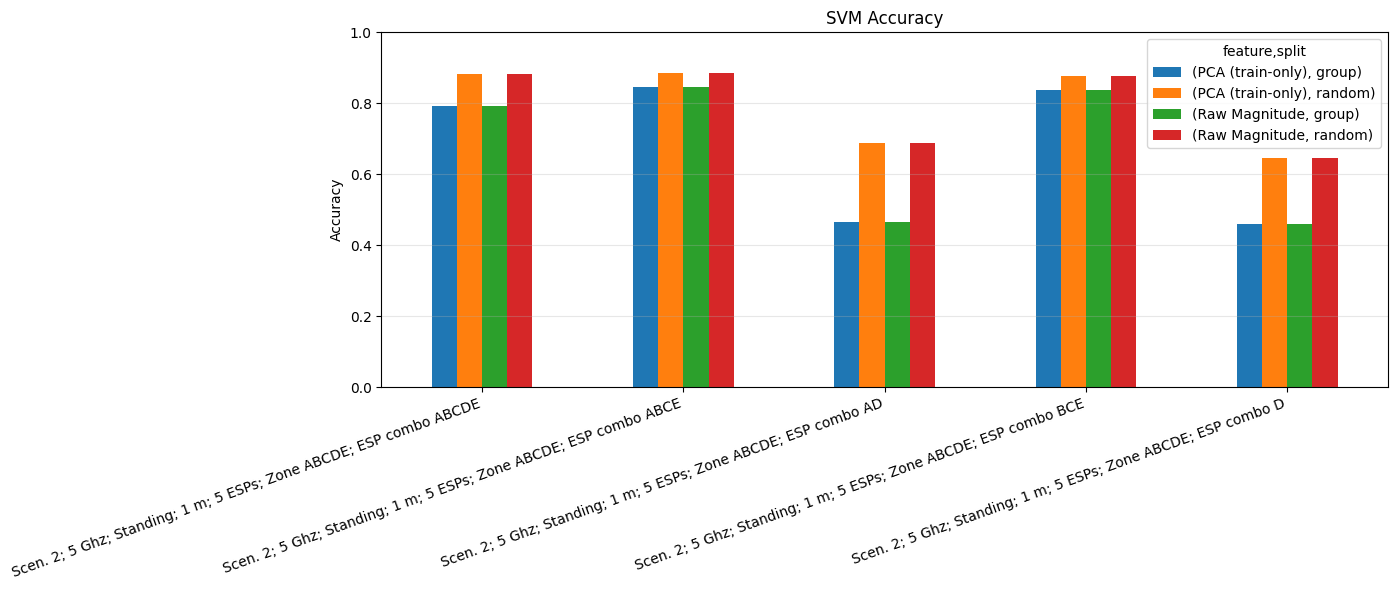

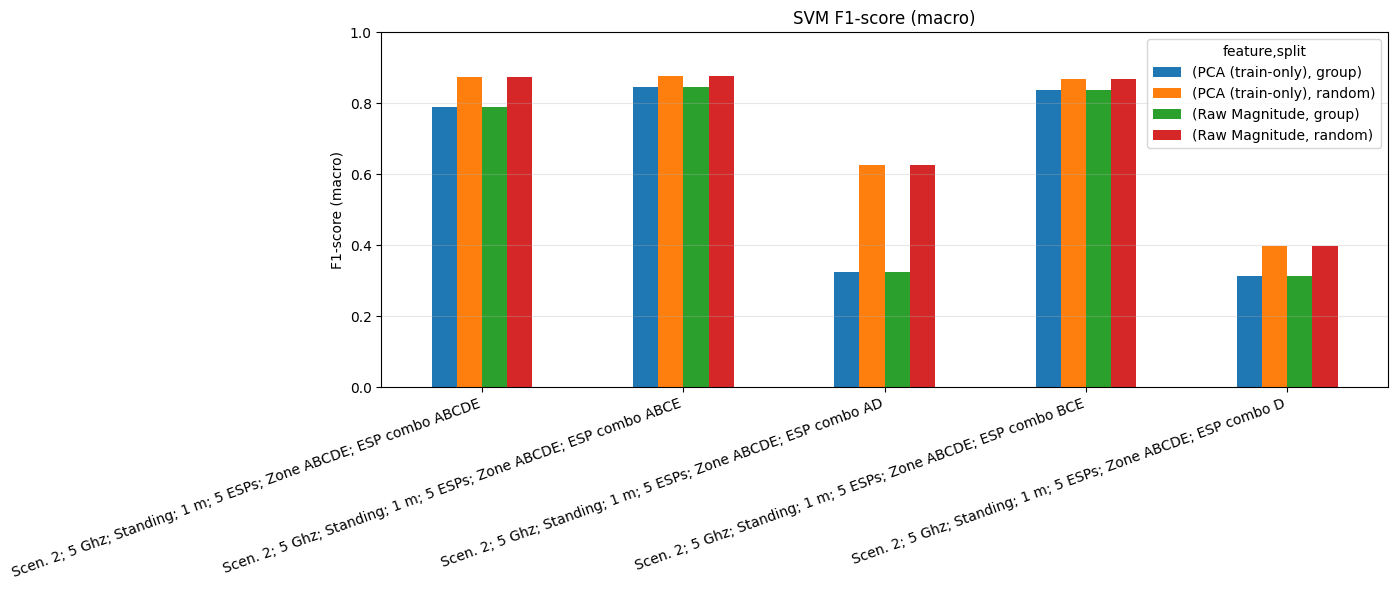

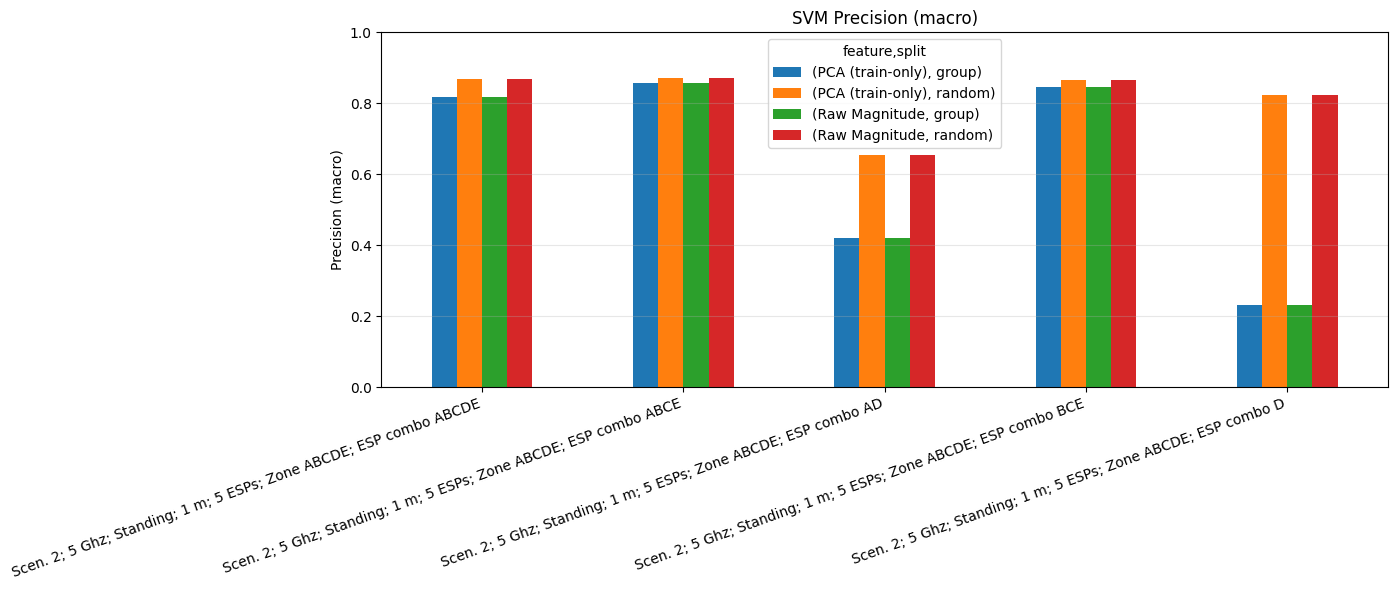

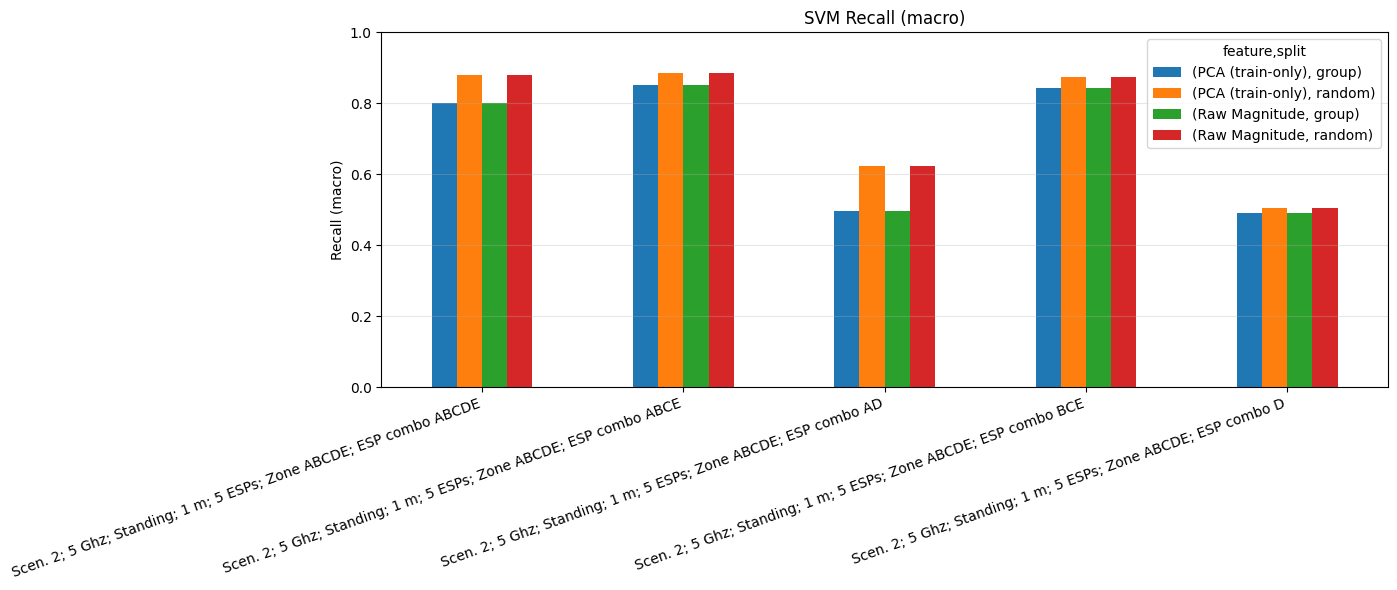

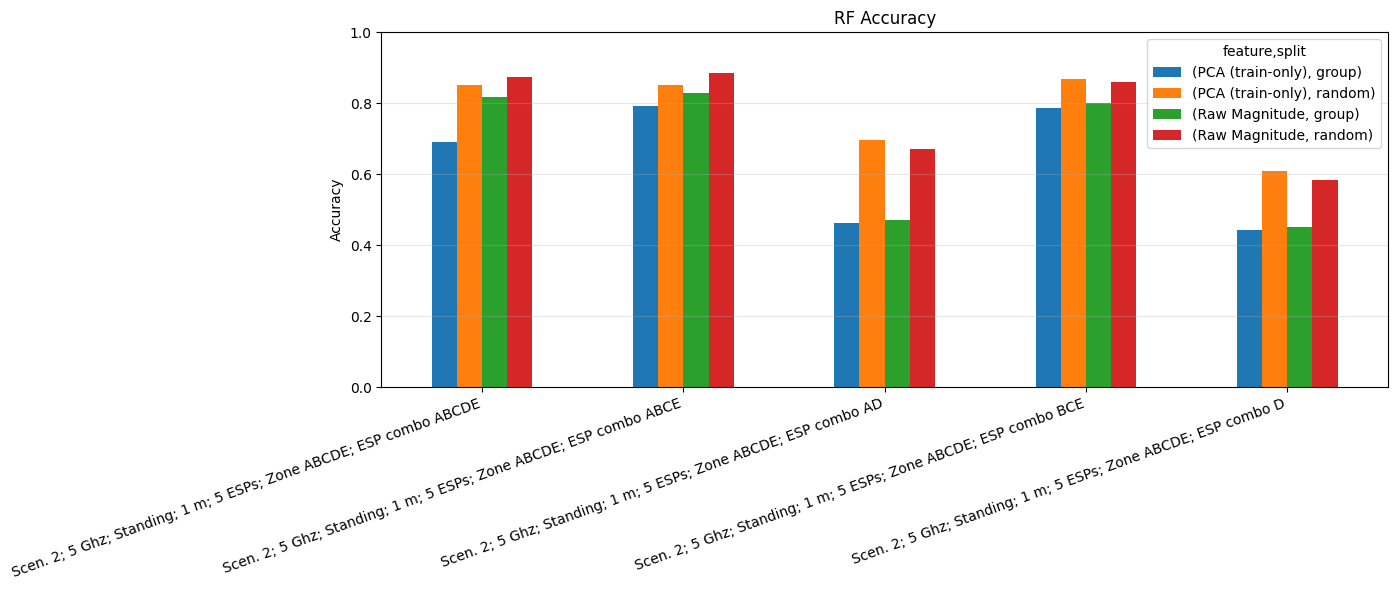

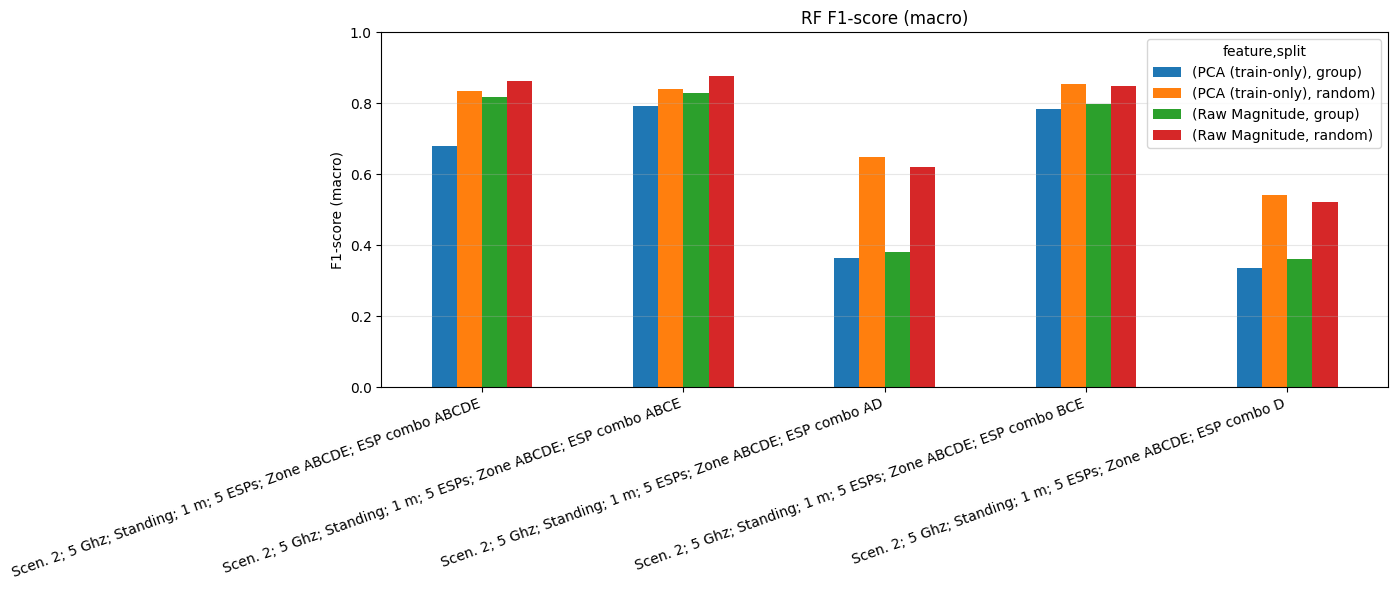

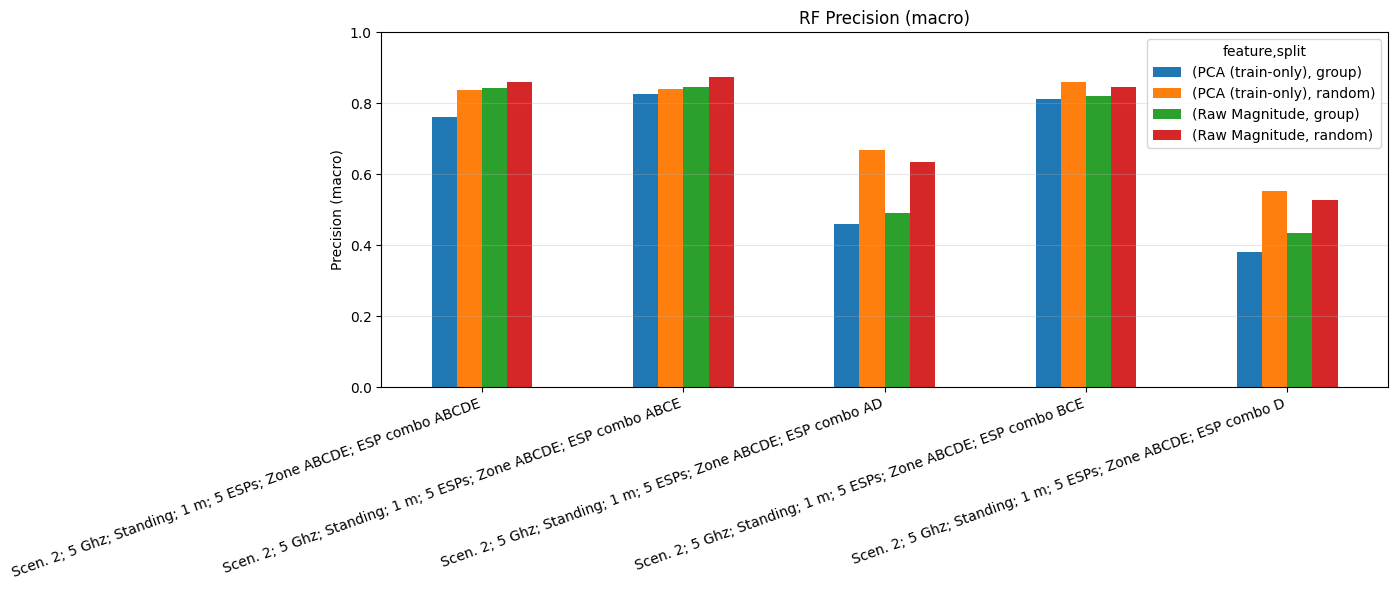

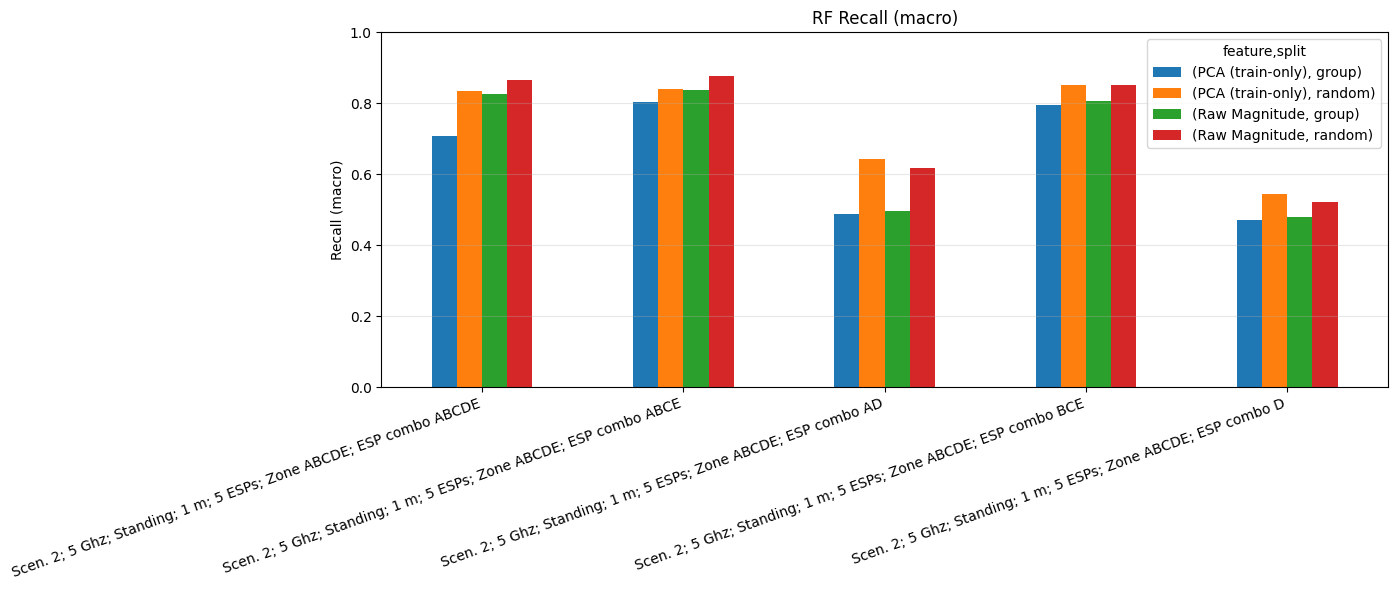

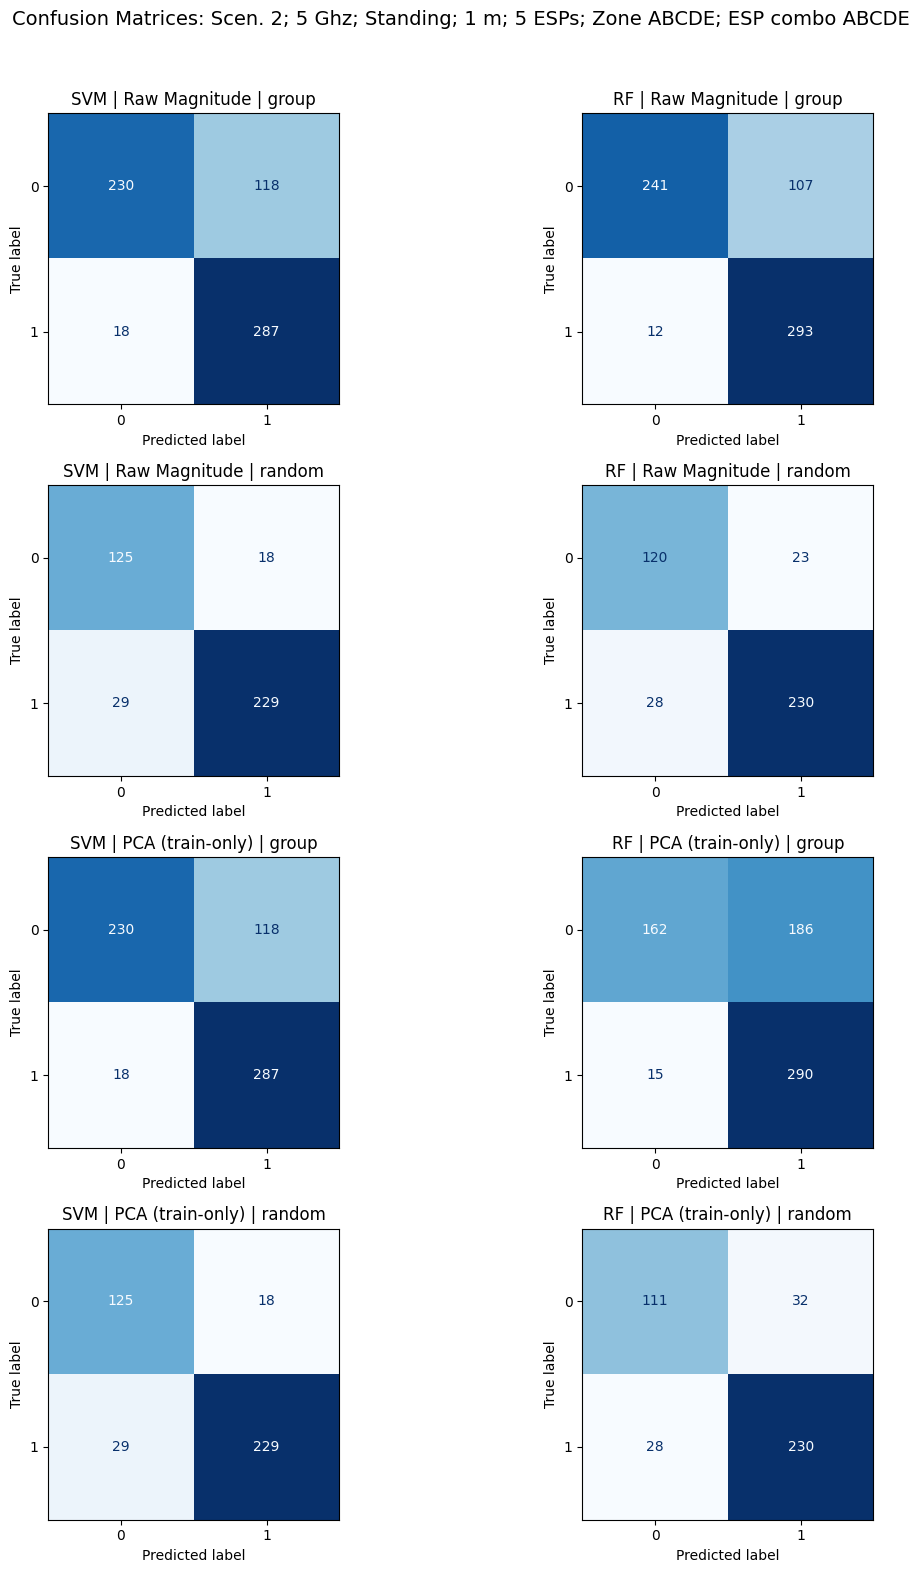

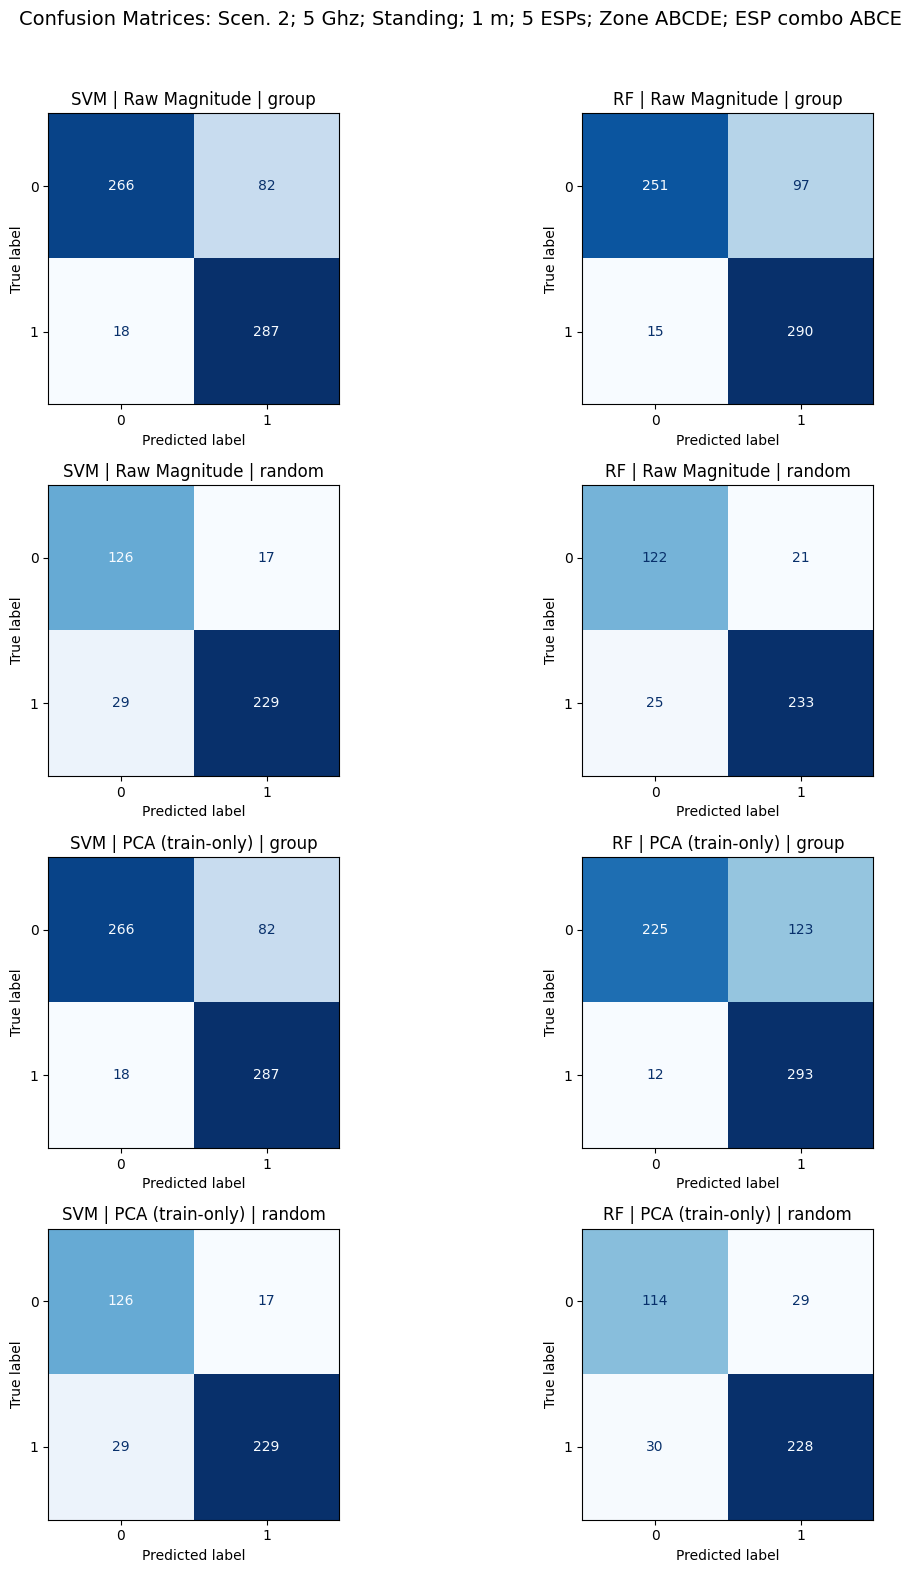

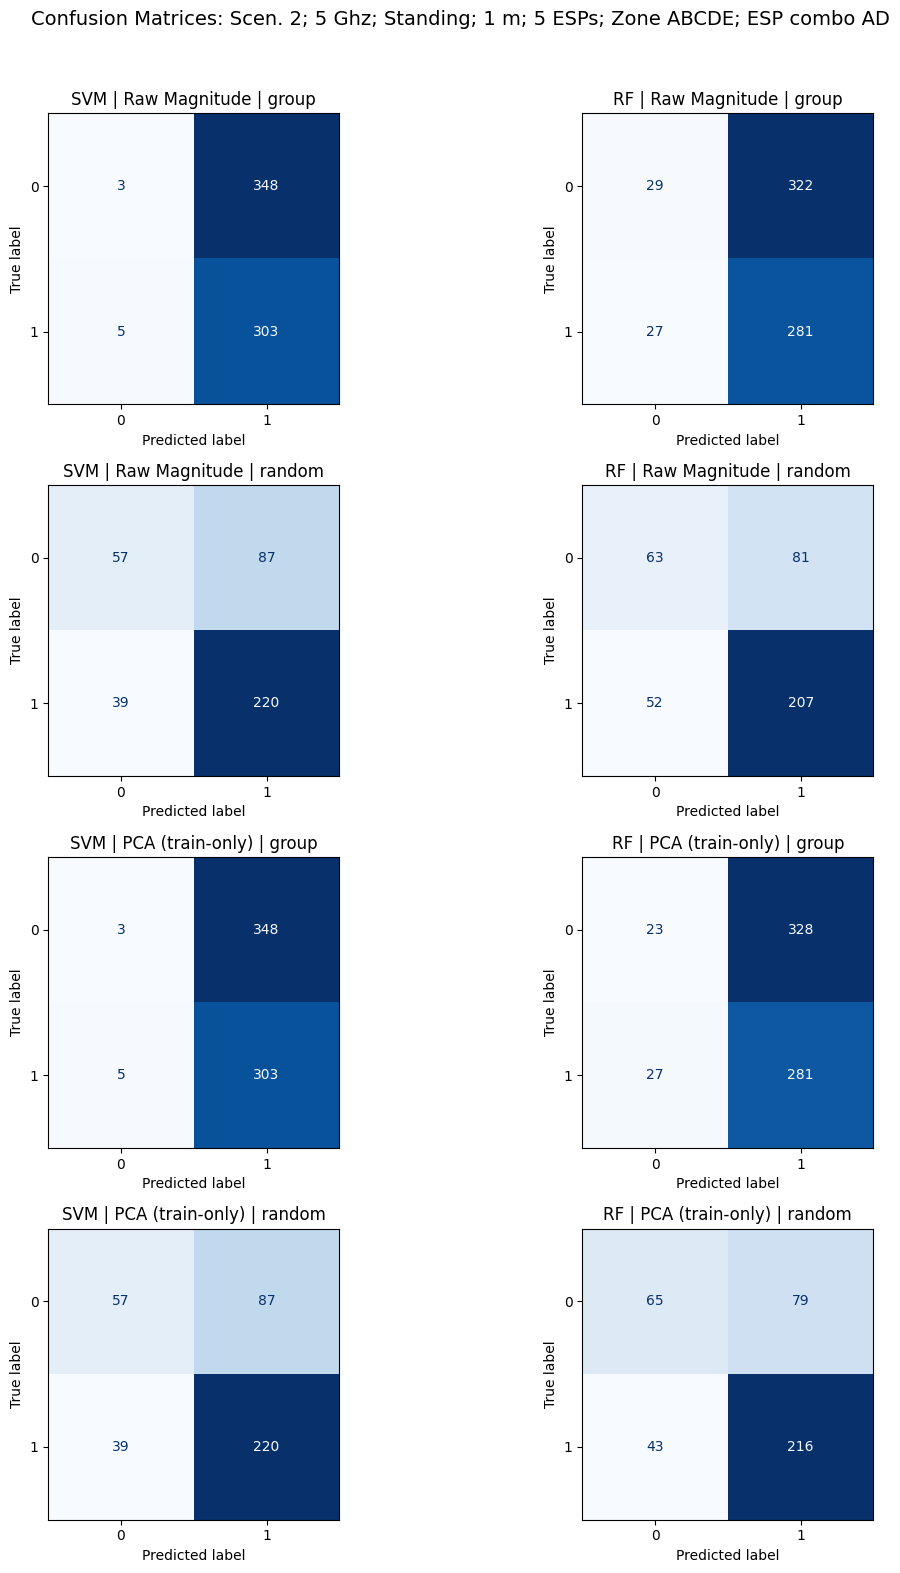

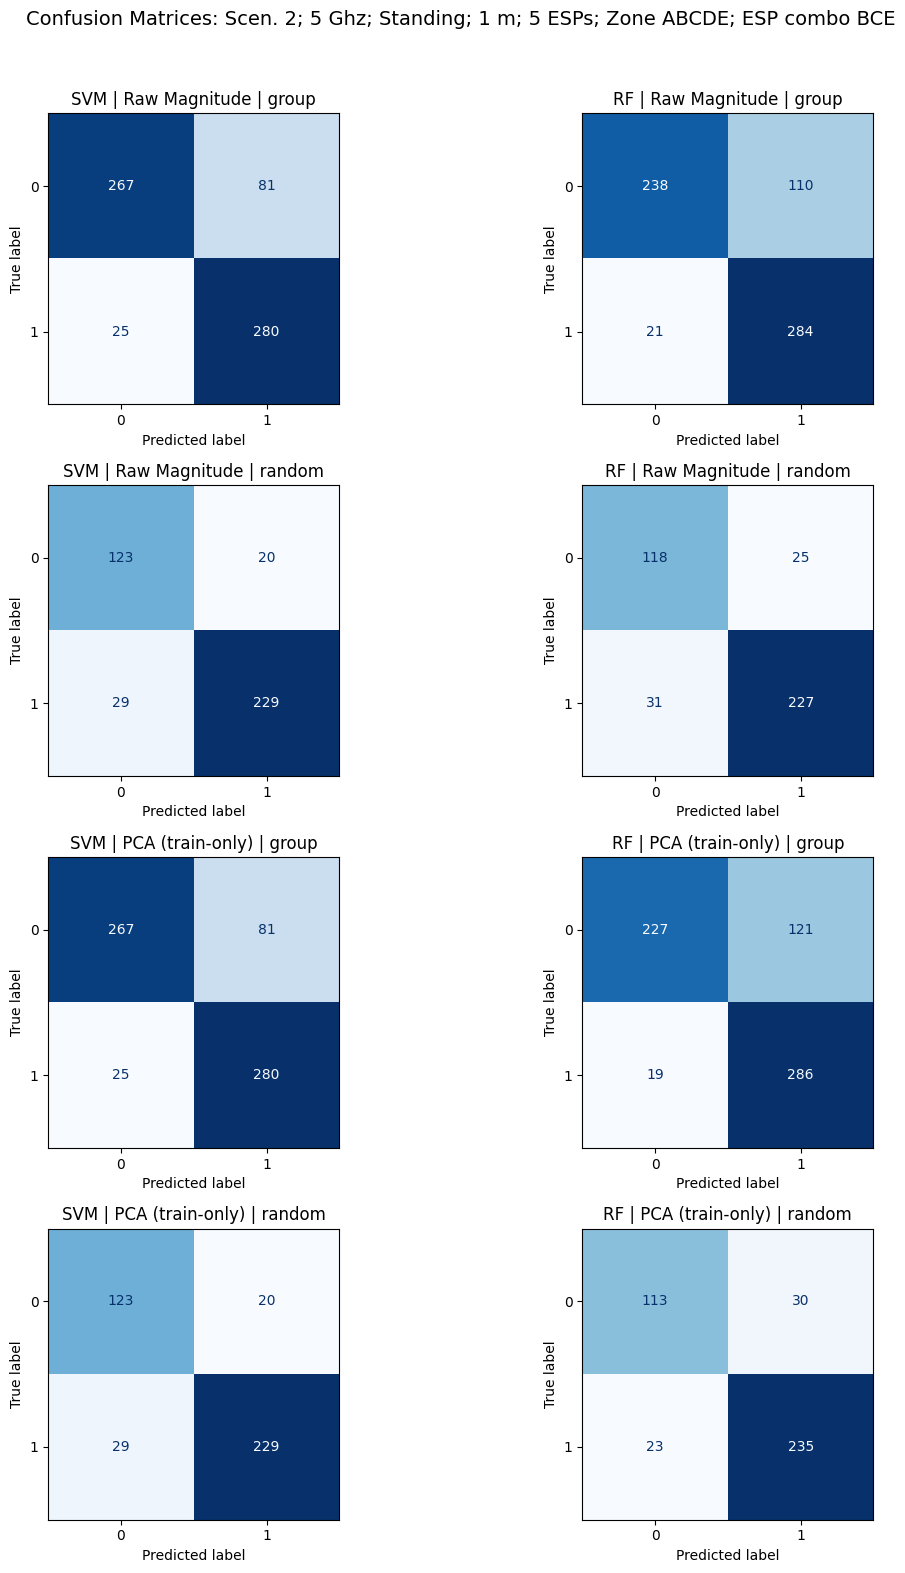

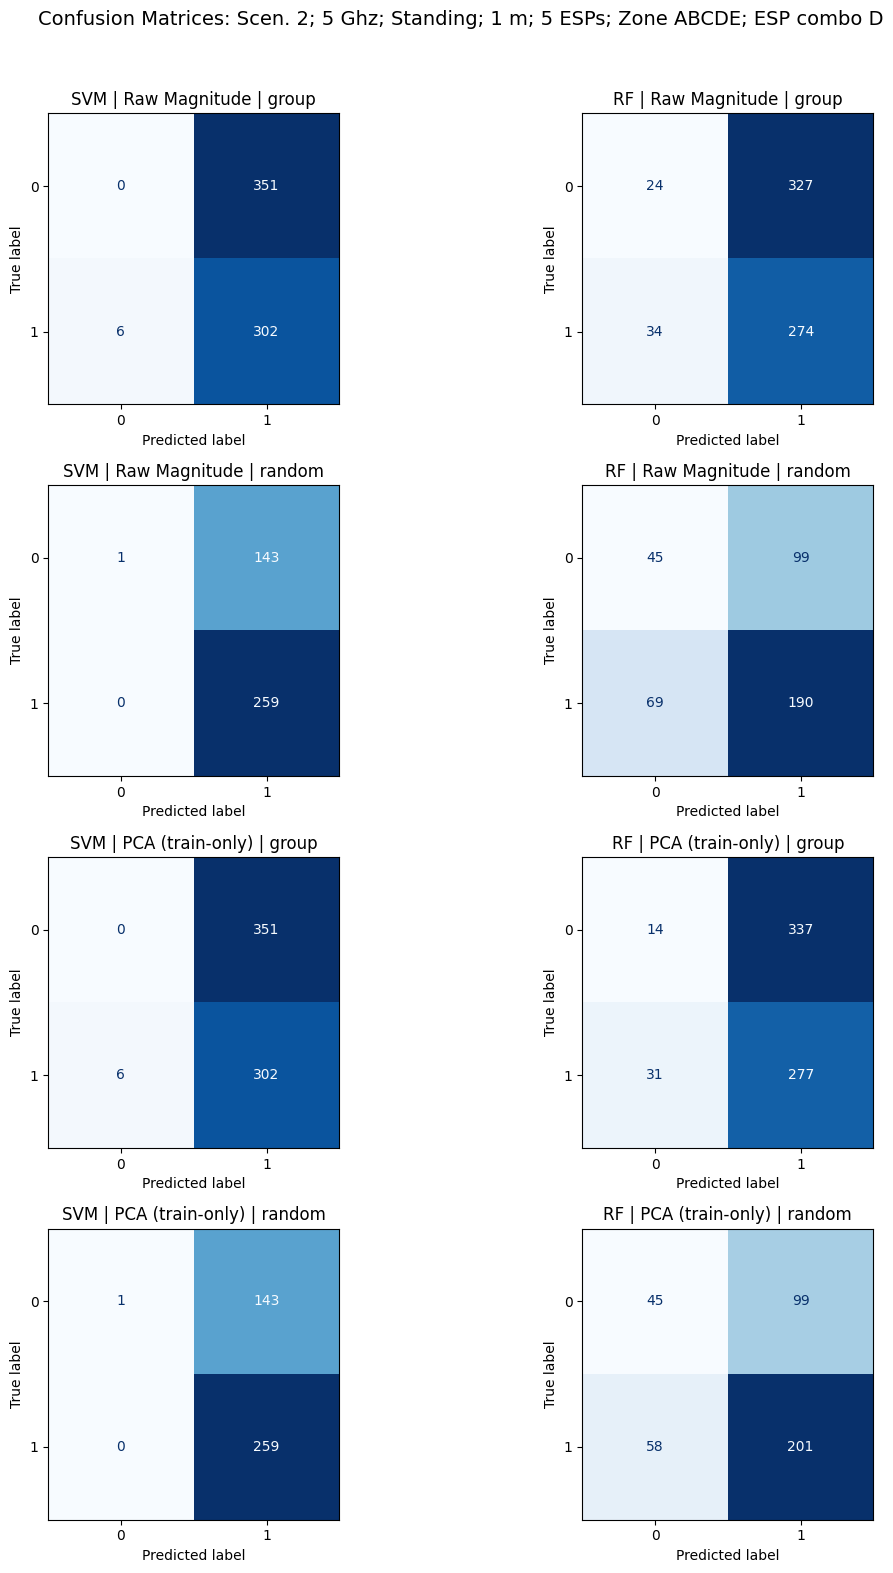


STATUS TABLE
         feature  split                        scenario  status reason
PCA (train-only)  group scenario_22215_ABCDE__ESP_ABCDE trained       
PCA (train-only)  group  scenario_22215_ABCDE__ESP_ABCE trained       
PCA (train-only)  group    scenario_22215_ABCDE__ESP_AD trained       
PCA (train-only)  group   scenario_22215_ABCDE__ESP_BCE trained       
PCA (train-only)  group     scenario_22215_ABCDE__ESP_D trained       
PCA (train-only) random scenario_22215_ABCDE__ESP_ABCDE trained       
PCA (train-only) random  scenario_22215_ABCDE__ESP_ABCE trained       
PCA (train-only) random    scenario_22215_ABCDE__ESP_AD trained       
PCA (train-only) random   scenario_22215_ABCDE__ESP_BCE trained       
PCA (train-only) random     scenario_22215_ABCDE__ESP_D trained       
   Raw Magnitude  group scenario_22215_ABCDE__ESP_ABCDE trained       
   Raw Magnitude  group  scenario_22215_ABCDE__ESP_ABCE trained       
   Raw Magnitude  group    scenario_22215_ABCDE__ESP_AD trained

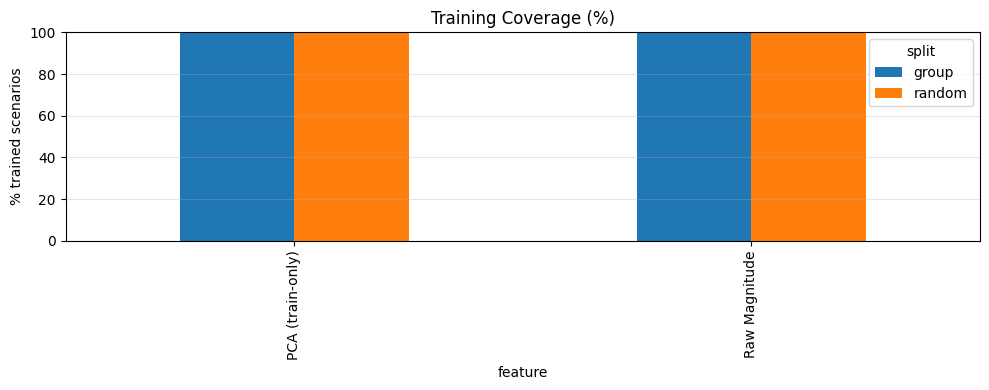


DETAILED RESULTS
         feature  split                        scenario model  accuracy  f1_macro  precision_macro  recall_macro
PCA (train-only)  group scenario_22215_ABCDE__ESP_ABCDE    RF  0.692190  0.679890         0.762249      0.708168
PCA (train-only)  group scenario_22215_ABCDE__ESP_ABCDE   SVM  0.791730  0.790131         0.818031      0.800952
PCA (train-only)  group  scenario_22215_ABCDE__ESP_ABCE    RF  0.793262  0.790995         0.826847      0.803604
PCA (train-only)  group  scenario_22215_ABCDE__ESP_ABCE   SVM  0.846861  0.846702         0.857199      0.852676
PCA (train-only)  group    scenario_22215_ABCDE__ESP_AD    RF  0.461305  0.363791         0.460706      0.488932
PCA (train-only)  group    scenario_22215_ABCDE__ESP_AD   SVM  0.464340  0.324311         0.420219      0.496157
PCA (train-only)  group   scenario_22215_ABCDE__ESP_BCE    RF  0.785605  0.783840         0.812733      0.795002
PCA (train-only)  group   scenario_22215_ABCDE__ESP_BCE   SVM  0.837672  0.837

In [104]:
# Reuse the global scenario filter defined in Cell 4.
# If Cell 4 was not run yet, fallback to all scenarios found in the results.
if "selected_scenarios" not in globals():
    selected_scenarios: list[str] | None = None


def format_scenario_tick_label(scenario_id: str) -> str:
    parts = scenario_id_to_label(scenario_id).split(", ")
    if len(parts) <= 2:
        return scenario_id_to_label(scenario_id)

    # Split long scenario labels across two lines for readability.
    midpoint = (len(parts) + 1) // 2
    top = ", ".join(parts[:midpoint])
    bottom = ", ".join(parts[midpoint:])
    return f"{top}\n{bottom}"


rows = []
confusion_rows = []
for feat, split_map in model_results_all.items():
    for split, scen_map in split_map.items():
        for scenario, model_map in scen_map.items():
            for model_name in ["SVM", "RF"]:
                if model_name not in model_map:
                    continue

                result = model_map[model_name]
                report = result.get("report", {})
                macro_avg = report.get("macro avg", {}) if isinstance(report, dict) else {}

                rows.append(
                    {
                        "feature": feat,
                        "split": split,
                        "scenario": scenario,
                        "model": model_name,
                        "accuracy": result.get("accuracy", np.nan),
                        "f1_macro": result.get("f1_macro", macro_avg.get("f1-score", np.nan)),
                        "precision_macro": macro_avg.get("precision", np.nan),
                        "recall_macro": macro_avg.get("recall", np.nan),
                    }
                )
                confusion_rows.append(
                    {
                        "feature": feat,
                        "split": split,
                        "scenario": scenario,
                        "model": model_name,
                        "confusion_matrix": result.get("confusion_matrix"),
                        "class_labels": result.get("class_labels", []),
                    }
                )

results_df = pd.DataFrame(rows)
confusion_df = pd.DataFrame(confusion_rows)

status_rows = []
for feat, split_map in experiment_run_info.items():
    for split, scen_map in split_map.items():
        for scenario, info in scen_map.items():
            status_rows.append(
                {
                    "feature": feat,
                    "split": split,
                    "scenario": scenario,
                    "status": info.get("status", "skipped"),
                    "reason": info.get("skip_reason", ""),
                }
            )
status_df = pd.DataFrame(status_rows)

available_scenarios = sorted(
    set(results_df["scenario"].unique())
    if not results_df.empty
    else set(status_df["scenario"].unique())
)
selected_scenario_ids, unresolved_scenarios = resolve_selected_scenarios(
    selected_scenarios,
    available_scenarios,
)

if unresolved_scenarios:
    print("[WARN] Some selected scenarios were not found and will be ignored:")
    print(unresolved_scenarios)

if available_scenarios:
    print("Scenarios used in this comparison:")
    for sid in sorted(selected_scenario_ids):
        print(f"  - {sid}: {scenario_id_to_label(sid)}")
else:
    print("No scenarios available yet.")

if not results_df.empty:
    results_df = results_df[results_df["scenario"].isin(selected_scenario_ids)].copy()
if not confusion_df.empty:
    confusion_df = confusion_df[confusion_df["scenario"].isin(selected_scenario_ids)].copy()
if not status_df.empty:
    status_df = status_df[status_df["scenario"].isin(selected_scenario_ids)].copy()

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("f1_macro", "F1-score (macro)"),
    ("precision_macro", "Precision (macro)"),
    ("recall_macro", "Recall (macro)"),
]

if results_df.empty:
    print(
        "No trained results found for the selected scenarios. Run training first or change selected_scenarios."
    )
else:
    for model_name in ["SVM", "RF"]:
        model_df = results_df[results_df["model"] == model_name]

        for metric_col, metric_title in metrics_to_plot:
            metric_df = model_df.dropna(subset=[metric_col])
            if metric_df.empty:
                print(f"[SKIP] No values available for {model_name} - {metric_title}")
                continue

            pivot = metric_df.pivot_table(
                index="scenario",
                columns=["feature", "split"],
                values=metric_col,
                aggfunc="mean",
            )
            pivot.index = [format_scenario_tick_label(scenario) for scenario in pivot.index]
            ax = pivot.plot(
                kind="bar", figsize=(14, 6), ylim=(0, 1.0), title=f"{model_name} {metric_title}"
            )
            ax.set_ylabel(metric_title)
            ax.grid(axis="y", alpha=0.3)

            # Keep labels diagonal and right-aligned, but now with shorter two-line labels.
            ax.tick_params(axis="x", labelrotation=20)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment("right")

            plt.tight_layout()
            plt.show()

feature_order = list(model_results_all.keys())
split_order = ["group", "random"]
model_order = ["SVM", "RF"]

if confusion_df.empty:
    print("No confusion matrices found for the selected scenarios.")
else:
    scenario_order = [
        scenario_key
        for scenario_key in sorted(selected_scenario_ids)
        if scenario_key in set(confusion_df["scenario"].unique())
    ]

    for scenario_key in scenario_order:
        scenario_cm_df = confusion_df[confusion_df["scenario"] == scenario_key].copy()
        scenario_cm_df["feature"] = pd.Categorical(
            scenario_cm_df["feature"],
            categories=feature_order,
            ordered=True,
        )
        scenario_cm_df["split"] = pd.Categorical(
            scenario_cm_df["split"],
            categories=split_order,
            ordered=True,
        )
        scenario_cm_df["model"] = pd.Categorical(
            scenario_cm_df["model"],
            categories=model_order,
            ordered=True,
        )
        scenario_cm_df = scenario_cm_df.sort_values(["feature", "split", "model"]).reset_index(
            drop=True
        )

        n_panels = len(scenario_cm_df)
        n_cols = 2
        n_rows = int(np.ceil(n_panels / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)
        axes = axes.ravel()

        for axis, (_, row) in zip(axes, scenario_cm_df.iterrows()):
            matrix = row["confusion_matrix"]
            labels = row["class_labels"]

            if matrix is None or len(labels) == 0:
                axis.text(0.5, 0.5, "No confusion matrix", ha="center", va="center")
                axis.set_axis_off()
                continue

            matrix = np.asarray(matrix)
            display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
            display.plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
            axis.set_title(f"{row['model']} | {row['feature']} | {row['split']}")
            axis.grid(False)

        for axis in axes[n_panels:]:
            axis.set_axis_off()

        fig.suptitle(f"Confusion Matrices: {scenario_id_to_label(scenario_key)}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

if status_df.empty:
    print("No status metadata found for the selected scenarios.")
else:
    print("\nSTATUS TABLE")
    print(status_df.sort_values(["feature", "split", "scenario"]).to_string(index=False))

    coverage = status_df.assign(trained=(status_df["status"] == "trained").astype(int))
    cov = coverage.groupby(["feature", "split"], as_index=False)["trained"].mean()
    cov["trained_pct"] = cov["trained"] * 100
    ax = cov.pivot(index="feature", columns="split", values="trained_pct").plot(
        kind="bar", figsize=(10, 4), ylim=(0, 100), title="Training Coverage (%)"
    )
    ax.set_ylabel("% trained scenarios")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nDETAILED RESULTS")
if results_df.empty:
    print("No results.")
else:
    print(
        results_df[
            [
                "feature",
                "split",
                "scenario",
                "model",
                "accuracy",
                "f1_macro",
                "precision_macro",
                "recall_macro",
            ]
        ]
        .sort_values(["feature", "split", "scenario", "model"])
        .to_string(index=False)
    )

print("\nCONFUSION MATRICES")
if confusion_df.empty:
    print("No confusion matrices.")
else:
    ordered_confusion_df = confusion_df.copy()
    ordered_confusion_df["feature"] = pd.Categorical(
        ordered_confusion_df["feature"],
        categories=feature_order,
        ordered=True,
    )
    ordered_confusion_df["split"] = pd.Categorical(
        ordered_confusion_df["split"],
        categories=split_order,
        ordered=True,
    )
    ordered_confusion_df["model"] = pd.Categorical(
        ordered_confusion_df["model"],
        categories=model_order,
        ordered=True,
    )

    for row in ordered_confusion_df.sort_values(
        ["scenario", "feature", "split", "model"]
    ).itertuples(index=False):
        print(f"\n{row.feature} | {row.split} | {row.model} | {scenario_id_to_label(row.scenario)}")
        print(np.asarray(row.confusion_matrix))

#### Parameter Study: Window and Overlap Size Impact

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# Define window and overlap combinations to test
window_overlap_configs = []
for i in range(1, 45, 5):
    for j in range(50, 200, 5):
        print(f"Window size: {j}, Overlap size: {i}")
        window_overlap_configs.append({"window_size": j, "overlap_size": i})


def split_group_param(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    test_size: float = 0.2,
    max_tries: int = 25,
) -> tuple[np.ndarray, np.ndarray, str] | tuple[None, None, str]:
    group_label_df = pd.DataFrame({"label": y.values, "group": groups.values}).drop_duplicates()
    groups_per_class = group_label_df.groupby("label")["group"].nunique()
    n_classes = int(group_label_df["label"].nunique())
    n_groups = int(group_label_df["group"].nunique())

    if groups_per_class.min() <= 1:
        return None, None, "unavailable"

    min_test_groups = n_classes
    requested_test_groups = int(np.ceil(n_groups * test_size))
    n_test_groups = max(min_test_groups, requested_test_groups)

    if n_groups - n_test_groups < n_classes:
        return None, None, "unavailable"

    for seed in range(max_tries):
        try:
            train_groups, test_groups = train_test_split(
                group_label_df["group"],
                test_size=n_test_groups,
                random_state=42 + seed,
                stratify=group_label_df["label"],
            )
        except ValueError:
            continue

        train_mask = groups.isin(train_groups)
        test_mask = groups.isin(test_groups)
        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        if y_train.nunique() >= 2 and y_test.nunique() >= 2:
            return train_idx, test_idx, "group"

    return None, None, "unavailable"


def split_random_param(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
) -> tuple[np.ndarray, np.ndarray, str]:
    idx = np.arange(len(X))
    try:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=y,
        )
    except ValueError:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=None,
        )
    return np.array(train_idx), np.array(test_idx), "random"


def sanitize_param_inputs(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    scenario_key: str,
    config_key: str,
    split_mode: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Series, bool]:
    y_numeric = pd.to_numeric(y, errors="coerce")
    valid_mask = y_numeric.notna()

    if not valid_mask.all():
        n_invalid = int((~valid_mask).sum())
        print(
            f"[WARN] Dropping {n_invalid} rows with invalid/NaN labels | "
            f"scenario={scenario_id_to_label(scenario_key)} | config={config_key} | split={split_mode}"
        )
        X = X.loc[valid_mask]
        y_numeric = y_numeric.loc[valid_mask]
        groups = groups.loc[valid_mask]

    if len(X) == 0:
        return X, y_numeric, groups, False

    y_numeric = y_numeric.astype(int)
    return X, y_numeric, groups, True


# Store results separately by split mode
param_study_results = {"group": {}, "random": {}}
split_modes_param = ["group", "random"]

for config in window_overlap_configs:
    window_size = config["window_size"]
    overlap_size = config["overlap_size"]
    config_key = f"w{window_size}_o{overlap_size}"

    print(f"\n{'=' * 80}")
    print(f"Testing: Window Size = {window_size}, Overlap Size = {overlap_size}")
    print("Split policy: evaluating BOTH group and random")
    print(f"{'=' * 80}\n")

    dataset_per_scenario_param = {}

    for scenario_key, users_map in magnitude_data.items():
        print(f"Building dataset for scenario {scenario_id_to_label(scenario_key)}\n")
        scenario_df = build_scenario_dataset(
            users_map,
            scenario_key,
            feature_type="raw",
            window_size=window_size,
            overlap_size=overlap_size,
        )
        dataset_per_scenario_param[scenario_key] = scenario_df
        print(f"Scenario {scenario_id_to_label(scenario_key)}: {scenario_df.shape[0]} windows")

    for split_mode in split_modes_param:
        param_study_results[split_mode][config_key] = {}

    for scenario_key, dataset in dataset_per_scenario_param.items():
        if dataset.empty:
            print(f"[SKIP] {scenario_id_to_label(scenario_key)}: empty dataset")
            continue

        if dataset["label"].nunique() < 2:
            print(f"[SKIP] {scenario_id_to_label(scenario_key)}: only one label present")
            continue

        feature_cols = [
            col
            for col in dataset.columns
            if col
            not in ["scenario", "user", "activity", "trial", "group_id", "window_idx", "label"]
        ]

        X = dataset[feature_cols]
        y = dataset["label"]
        groups = dataset["group_id"]

        for split_mode in split_modes_param:
            X_split, y_split, groups_split, has_valid_rows = sanitize_param_inputs(
                X,
                y,
                groups,
                scenario_key,
                config_key,
                split_mode,
            )
            if not has_valid_rows:
                print(
                    f"[SKIP] {scenario_id_to_label(scenario_key)} | {split_mode}: "
                    "no valid labels after sanitization",
                )
                continue

            if y_split.nunique() < 2:
                print(
                    f"[SKIP] {scenario_id_to_label(scenario_key)} | {split_mode}: "
                    "only one valid label after sanitization",
                )
                continue

            if split_mode == "group":
                train_idx, test_idx, resolved_mode = split_group_param(
                    X_split,
                    y_split,
                    groups_split,
                    test_size=0.2,
                )
            else:
                train_idx, test_idx, resolved_mode = split_random_param(
                    X_split, y_split, test_size=0.2
                )

            if train_idx is None:
                print(
                    f"[SKIP] {scenario_id_to_label(scenario_key)} | {split_mode}: "
                    "could not find valid split"
                )
                continue

            X_train, X_test = X_split.iloc[train_idx], X_split.iloc[test_idx]
            y_train, y_test = y_split.iloc[train_idx], y_split.iloc[test_idx]

            if y_train.nunique() < 2 or y_test.nunique() < 2:
                print(
                    f"[SKIP] {scenario_id_to_label(scenario_key)} | {split_mode}: "
                    "split has single class in train/test"
                )
                continue

            models = {
                "SVM": make_pipeline(
                    StandardScaler(),
                    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                ),
                "RF": RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    class_weight="balanced",
                ),
            }

            param_study_results[split_mode][config_key][scenario_key] = {}

            print(
                f"\n=== Scenario: {scenario_id_to_label(scenario_key)} | split={resolved_mode} ==="
            )
            for model_name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1_macro = f1_score(y_test, y_pred, average="macro")

                param_study_results[split_mode][config_key][scenario_key][model_name] = {
                    "accuracy": acc,
                    "f1_macro": f1_macro,
                    "split_mode": resolved_mode,
                }

                print(
                    f"{split_mode} | {model_name}: Accuracy = {acc:.4f}, F1-macro = {f1_macro:.4f}"
                )

print(f"\n{'=' * 80}")
print("Parameter study completed!")
print(f"{'=' * 80}\n")

In [ ]:
# Visualization of parameter study results (clearer heatmap view per split mode)
# Reuse the same scenario selection defined earlier.
# If not available yet, fallback to None (include all scenarios).
selected_param_scenarios: list[str] | None = (
    selected_scenarios if "selected_scenarios" in globals() else None
)


def _normalize_param_scenario_id(value: str) -> str:
    value_str = str(value).strip()
    if value_str.startswith("scenario_"):
        return value_str

    parts = value_str.split("_", 1)
    if len(parts) == 1 and len(value_str) == 5 and value_str.isdigit():
        return f"scenario_{value_str}"

    if len(parts) == 2 and len(parts[0]) == 5 and parts[0].isdigit() and parts[1].isalpha():
        return f"scenario_{parts[0]}_{parts[1].upper()}"

    return value_str


def _resolve_param_selected_scenarios(
    selected: list[str] | None,
    available_ids: list[str],
) -> tuple[set[str], list[str]]:
    if not selected:
        return set(available_ids), []

    available_set = set(available_ids)
    resolved: set[str] = set()
    unresolved: list[str] = []

    for item in selected:
        candidate = _normalize_param_scenario_id(item)
        if candidate in available_set:
            resolved.add(candidate)
        else:
            unresolved.append(item)

    return resolved, unresolved


def _parse_config_key(config_key: str) -> tuple[int, int]:
    window_part, overlap_part = config_key.split("_")
    return int(window_part[1:]), int(overlap_part[1:])


def _thin_tick_positions(values: list[int], max_ticks: int = 10) -> tuple[list[int], list[int]]:
    if len(values) <= max_ticks:
        return list(range(len(values))), values

    picked = np.linspace(0, len(values) - 1, max_ticks, dtype=int)
    picked = np.unique(picked)
    return picked.tolist(), [values[idx] for idx in picked]


def _format_top_configs(rows: list[tuple[float, int, int]], top_n: int = 3) -> str:
    if len(rows) == 0:
        return "No valid configs"

    ordered = sorted(rows, key=lambda item: item[0], reverse=True)[:top_n]
    return " | ".join(
        f"{score:.3f} @ w{window}/o{overlap}" for score, window, overlap in ordered
    )


split_modes_param = ["random", "group"]

if len(param_study_results) == 0:
    print("No parameter-study results available yet.")
else:
    all_param_scenarios = set()
    for split_mode in split_modes_param:
        split_results = param_study_results.get(split_mode, {})
        for config_key in split_results.keys():
            all_param_scenarios.update(split_results[config_key].keys())

    selected_param_ids, unresolved_param = _resolve_param_selected_scenarios(
        selected_param_scenarios,
        sorted(all_param_scenarios),
    )

    if unresolved_param:
        print("[WARN] Some selected parameter-study scenarios were not found and will be ignored:")
        print(unresolved_param)

    if selected_param_ids:
        print("Parameter-study scenarios selected:")
        for sid in sorted(selected_param_ids):
            print(f"  - {sid}: {scenario_id_to_label(sid)}")

    for split_mode in split_modes_param:
        split_results = param_study_results.get(split_mode, {})
        if len(split_results) == 0:
            print(f"No parameter-study results available for split={split_mode}.")
            continue

        config_keys = sorted(split_results.keys(), key=_parse_config_key)
        scenario_keys_set = set()
        for config_key in config_keys:
            scenario_keys_set.update(split_results[config_key].keys())

        scenario_keys_sorted = sorted(
            scenario_key for scenario_key in scenario_keys_set if scenario_key in selected_param_ids
        )

        if len(scenario_keys_sorted) == 0:
            print(f"No valid scenarios found for split={split_mode} after filtering.")
            continue

        parsed_configs = [_parse_config_key(config_key) for config_key in config_keys]
        unique_windows = sorted({window for window, _ in parsed_configs})
        unique_overlaps = sorted({overlap for _, overlap in parsed_configs})
        window_to_idx = {window: idx for idx, window in enumerate(unique_windows)}
        overlap_to_idx = {overlap: idx for idx, overlap in enumerate(unique_overlaps)}

        split_title = "Random Split" if split_mode == "random" else "Group Split"
        n_scenarios = len(scenario_keys_sorted)
        fig, axes = plt.subplots(
            n_scenarios,
            2,
            figsize=(16, max(4.5 * n_scenarios, 6)),
            squeeze=False,
            sharex=True,
            sharey=True,
        )

        color_mesh = None

        for row_idx, scenario_key in enumerate(scenario_keys_sorted):
            svm_grid = np.full((len(unique_overlaps), len(unique_windows)), np.nan)
            rf_grid = np.full((len(unique_overlaps), len(unique_windows)), np.nan)
            svm_rows: list[tuple[float, int, int]] = []
            rf_rows: list[tuple[float, int, int]] = []

            for config_key in config_keys:
                if scenario_key not in split_results[config_key]:
                    continue

                window, overlap = _parse_config_key(config_key)
                col_idx = window_to_idx[window]
                row_grid_idx = overlap_to_idx[overlap]

                svm_acc = split_results[config_key][scenario_key]["SVM"]["accuracy"]
                rf_acc = split_results[config_key][scenario_key]["RF"]["accuracy"]

                svm_grid[row_grid_idx, col_idx] = svm_acc
                rf_grid[row_grid_idx, col_idx] = rf_acc
                svm_rows.append((svm_acc, window, overlap))
                rf_rows.append((rf_acc, window, overlap))

            scenario_label = scenario_id_to_label(scenario_key)
            model_grids = [
                ("SVM", svm_grid, svm_rows),
                ("RF", rf_grid, rf_rows),
            ]

            for col_idx, (model_name, grid, score_rows) in enumerate(model_grids):
                ax = axes[row_idx, col_idx]
                color_mesh = ax.imshow(
                    grid,
                    origin="lower",
                    aspect="auto",
                    cmap="cividis",
                    vmin=0.0,
                    vmax=1.0,
                )

                x_tick_pos, x_tick_labels = _thin_tick_positions(unique_windows, max_ticks=10)
                y_tick_pos, y_tick_labels = _thin_tick_positions(unique_overlaps, max_ticks=10)
                ax.set_xticks(x_tick_pos)
                ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=9)
                ax.set_yticks(y_tick_pos)
                ax.set_yticklabels(y_tick_labels, fontsize=9)

                if row_idx == n_scenarios - 1:
                    ax.set_xlabel("Window size", fontsize=11, fontweight="bold")
                if col_idx == 0:
                    ax.set_ylabel("Overlap size", fontsize=11, fontweight="bold")

                top_summary = _format_top_configs(score_rows, top_n=3)
                ax.set_title(
                    f"{scenario_label}\n{model_name} | Top: {top_summary}",
                    fontsize=10,
                    fontweight="bold",
                )

                if len(score_rows) > 0:
                    best_score, best_window, best_overlap = max(score_rows, key=lambda item: item[0])
                    ax.scatter(
                        window_to_idx[best_window],
                        overlap_to_idx[best_overlap],
                        s=150,
                        facecolors="none",
                        edgecolors="white",
                        linewidths=2.2,
                    )
                    ax.text(
                        window_to_idx[best_window],
                        overlap_to_idx[best_overlap],
                        f"{best_score:.3f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white",
                        fontweight="bold",
                    )

        fig.suptitle(
            f"Parameter Study Heatmaps by Scenario ({split_title})\n"
            "Brightness shows accuracy; white circle marks the best configuration.",
            fontsize=14,
            fontweight="bold",
        )

        if color_mesh is not None:
            cbar = fig.colorbar(color_mesh, ax=axes, shrink=0.92, pad=0.02)
            cbar.set_label("Accuracy", fontsize=11, fontweight="bold")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


# Summary table
print("\n" + "=" * 100)
print("PARAMETER STUDY SUMMARY - Accuracy Results")
print("=" * 100)

if len(param_study_results) == 0:
    print("No results to summarize.")
else:
    for split_mode in split_modes_param:
        split_results = param_study_results.get(split_mode, {})
        if len(split_results) == 0:
            continue

        print(f"\n--- {split_mode.upper()} SPLIT ---")
        rows = []

        for config_key in sorted(split_results.keys(), key=_parse_config_key):
            window_size, overlap_size = _parse_config_key(config_key)
            for scenario_key, model_results in split_results[config_key].items():
                rows.append(
                    {
                        "scenario": scenario_id_to_label(scenario_key),
                        "window_size": window_size,
                        "overlap_size": overlap_size,
                        "svm_accuracy": model_results["SVM"]["accuracy"],
                        "rf_accuracy": model_results["RF"]["accuracy"],
                    }
                )

        summary_df = pd.DataFrame(rows)
        if summary_df.empty:
            print("No valid rows for this split.")
            continue

        best_per_scenario = (
            summary_df.assign(best_accuracy=summary_df[["svm_accuracy", "rf_accuracy"]].max(axis=1))
            .sort_values(["scenario", "best_accuracy"], ascending=[True, False])
            .groupby("scenario", as_index=False)
            .first()
        )

        print("Best configuration per scenario:")
        print(best_per_scenario.to_string(index=False))


In [ ]:
# Additional analysis: SNR, performance stability, RF feature importance, variance distributions

# Jupyter's `display()` can be overwritten elsewhere in the notebook (e.g., by ConfusionMatrixDisplay).
# Use a safe alias here.
try:
    from IPython.display import display as ipy_display
except Exception:
    ipy_display = None

# 1) Approximate scenario-level SNR using PCA pc1_energy_* features
snr_rows: list[dict[str, object]] = []

for scenario_key, df_pca in dataset_per_scenario_pca.items():
    if df_pca.empty:
        continue

    energy_cols = [c for c in df_pca.columns if c.startswith("pc1_energy_")]
    if not energy_cols:
        continue

    energy_vals = df_pca[energy_cols].values.ravel()
    signal_power = float(np.mean(energy_vals))
    noise_power = float(np.std(energy_vals))

    snr_rows.append(
        {
            "scenario": scenario_key,
            "snr_ratio": signal_power / (noise_power + 1e-8),
            "signal_power_mean": signal_power,
            "noise_std": noise_power,
            "n_samples": int(len(energy_vals)),
        },
    )

snr_df = pd.DataFrame(snr_rows)
if not snr_df.empty:
    snr_df["scenario_label"] = snr_df["scenario"].map(scenario_id_to_label)
    if ipy_display is not None:
        ipy_display(snr_df)
    else:
        print(snr_df)

    # Optional SNR bar plot per scenario
    plt.figure(figsize=(8, 4))
    ax = snr_df.set_index("scenario_label")["snr_ratio"].plot(kind="bar")
    ax.set_ylabel("Approx. SNR (mean energy / std energy)")
    ax.set_title("Scenario-level SNR (PCA pc1_energy)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No SNR values computed (missing pc1_energy_* features or empty datasets).")

# 2) Performance stability: mean and std accuracy across scenarios
if results_df.empty:
    print("[INFO] No trained results available for stability analysis.")
    stability_df = pd.DataFrame()
else:
    stability_df = (
        results_df.groupby(["feature", "split", "model"])["accuracy"]
        .agg(
            mean_accuracy="mean",
            std_accuracy="std",
            n_scenarios="count",
        )
        .reset_index()
    )

    print("\nPerformance stability (mean/std accuracy across scenarios):")
    if ipy_display is not None:
        ipy_display(stability_df)
    else:
        print(stability_df)

    # Optional: RF-only stability bar plot
    rf_stability = stability_df[stability_df["model"] == "RF"].copy()
    if not rf_stability.empty:
        plt.figure(figsize=(8, 4))
        x_labels = rf_stability["feature"] + " | " + rf_stability["split"]
        x = np.arange(len(x_labels))
        plt.bar(
            x=x, height=rf_stability["mean_accuracy"], yerr=rf_stability["std_accuracy"], capsize=5
        )
        plt.xticks(x, x_labels, rotation=20, ha="right")
        plt.ylabel("Accuracy")
        plt.title("RF performance stability (mean Â± std across scenarios)")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

# 3) RF feature importance for a reference scenario (Raw Magnitude)
#    You can change `reference_scenario_key` below to inspect a different scenario.
reference_scenario_key = None

# Prefer a scenario present in results_df for RF, falling back to any raw dataset
if reference_scenario_key is None:
    rf_scenarios: list[str] = []
    if not results_df.empty:
        rf_scenarios = results_df[(results_df["model"] == "RF")]["scenario"].unique().tolist()
    if rf_scenarios:
        reference_scenario_key = rf_scenarios[0]
    elif dataset_per_scenario_raw:
        reference_scenario_key = sorted(dataset_per_scenario_raw.keys())[0]

if reference_scenario_key is not None and reference_scenario_key in dataset_per_scenario_raw:
    ref_df = dataset_per_scenario_raw[reference_scenario_key].copy()
    if ref_df["label"].nunique() >= 2:
        feature_cols_rf = [
            col
            for col in ref_df.columns
            if col
            not in [
                "scenario",
                "user",
                "activity",
                "trial",
                "group_id",
                "window_idx",
                "label",
            ]
        ]

        X_ref = ref_df[feature_cols_rf]
        y_ref = ref_df["label"]

        X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(
            X_ref,
            y_ref,
            test_size=0.2,
            stratify=y_ref,
            random_state=42,
        )

        rf_ref = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
        )
        rf_ref.fit(X_train_ref, y_train_ref)

        importances = rf_ref.feature_importances_
        rf_importance_df = (
            pd.DataFrame({"feature": feature_cols_rf, "importance": importances})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        print(
            f"\nRF feature importance â€“ reference scenario: {scenario_id_to_label(reference_scenario_key)}",
        )
        if ipy_display is not None:
            ipy_display(rf_importance_df.head(20))
        else:
            print(rf_importance_df.head(20))

        # Optional: top-K importance bar plot
        top_k = min(20, len(rf_importance_df))
        top_imp = rf_importance_df.head(top_k)
        plt.figure(figsize=(10, 5))
        plt.barh(top_imp["feature"], top_imp["importance"])
        plt.gca().invert_yaxis()
        plt.xlabel("Importance")
        plt.title(
            "RF feature importance â€“ "
            + scenario_id_to_label(reference_scenario_key)
            + " (Raw Magnitude)",
        )
        plt.tight_layout()
        plt.show()

        # Aggregate importance by statistic prefix (e.g., variance, energy)
        rf_importance_df["stat"] = rf_importance_df["feature"].str.split("_").str[0]
        stat_importance = (
            rf_importance_df.groupby("stat")["importance"].sum().sort_values(ascending=False)
        )
        print("\nAggregated RF importance by statistic prefix:")
        if ipy_display is not None:
            ipy_display(stat_importance)
        else:
            print(stat_importance)
    else:
        print(
            f"[INFO] Reference scenario {scenario_id_to_label(reference_scenario_key)} "
            "does not have at least two labels for RF feature importance.",
        )
else:
    print("[INFO] No suitable reference scenario found for RF feature importance.")

# 4) Variance feature distribution across scenarios (Raw Magnitude)
var_rows: list[dict[str, object]] = []

for scenario_key, df_raw in dataset_per_scenario_raw.items():
    if df_raw.empty:
        continue

    variance_cols = [c for c in df_raw.columns if c.startswith("variance_")]
    if not variance_cols:
        continue

    vals = df_raw[variance_cols].values.ravel()
    var_rows.append(
        {
            "scenario": scenario_key,
            "mean_variance": float(np.mean(vals)),
            "std_variance": float(np.std(vals)),
            "median_variance": float(np.median(vals)),
            "n_values": int(len(vals)),
        },
    )

variance_summary_df = pd.DataFrame(var_rows)
if not variance_summary_df.empty:
    variance_summary_df["scenario_label"] = variance_summary_df["scenario"].map(
        scenario_id_to_label,
    )
    print("\nVariance feature summary (Raw Magnitude):")
    if ipy_display is not None:
        ipy_display(variance_summary_df)
    else:
        print(variance_summary_df)

    # Optional: KDE plot of variance distributions per scenario (requires seaborn)
    try:
        import seaborn as sns

        plt.figure(figsize=(10, 5))
        for scenario_key, df_raw in dataset_per_scenario_raw.items():
            variance_cols = [c for c in df_raw.columns if c.startswith("variance_")]
            if not variance_cols:
                continue

            vals = df_raw[variance_cols].values.ravel()
            if len(vals) == 0:
                continue

            sns.kdeplot(
                vals,
                label=scenario_id_to_label(scenario_key),
                fill=True,
                alpha=0.3,
            )

        plt.xlabel("Variance (raw magnitude features)")
        plt.title("Variance feature distribution across scenarios (Raw Magnitude)")
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[WARN] Could not generate variance KDE plots: {e}")
else:
    print("[INFO] No variance_* features found for distribution analysis.")


In [ ]:
# Experiment summary table: dataset stats + split info + metrics

# Compute scenario-level dataset stats from raw-magnitude datasets
scenario_stats: dict[str, dict[str, object]] = {}

for scenario_key, df_raw in dataset_per_scenario_raw.items():
    if df_raw.empty:
        continue

    n_windows_total = int(len(df_raw))
    n_groups_total = int(df_raw["group_id"].nunique()) if "group_id" in df_raw.columns else 0

    trials_per_class: dict[int, int] = {}
    groups_per_class: dict[int, int] = {}

    if "label" in df_raw.columns and "trial" in df_raw.columns:
        trial_counts = df_raw.groupby("label")["trial"].nunique()
        for lbl, cnt in trial_counts.items():
            trials_per_class[int(lbl)] = int(cnt)

    if "label" in df_raw.columns and "group_id" in df_raw.columns:
        group_counts = df_raw.groupby("label")["group_id"].nunique()
        for lbl, cnt in group_counts.items():
            groups_per_class[int(lbl)] = int(cnt)

    scenario_stats[scenario_key] = {
        "n_windows_total": n_windows_total,
        "n_groups_total": n_groups_total,
        "n_trials_per_class": trials_per_class,
        "n_groups_per_class": groups_per_class,
    }


# Build a consolidated table over (feature, split, scenario, model)
summary_rows: list[dict[str, object]] = []

for _, row in results_df.iterrows():
    feat = row["feature"]
    split = row["split"]
    scenario = row["scenario"]
    model_name = row["model"]

    # Base metrics from results_df
    acc = row.get("accuracy", float("nan"))
    f1_macro = row.get("f1_macro", float("nan"))
    prec_macro = row.get("precision_macro", float("nan"))
    rec_macro = row.get("recall_macro", float("nan"))

    # Experiment run info (status, reason, resolved split)
    run_info = experiment_run_info.get(feat, {}).get(split, {}).get(scenario, {})
    status = run_info.get("status", "unknown")
    reason = run_info.get("skip_reason", "")
    split_used = run_info.get("split_mode", split)
    n_samples = run_info.get("n_samples", float("nan"))
    n_groups = run_info.get("n_groups", float("nan"))
    n_features = run_info.get("n_features", float("nan"))

    # Scenario-level stats
    stats = scenario_stats.get(scenario, {})
    n_windows_total = stats.get("n_windows_total", float("nan"))
    n_groups_total = stats.get("n_groups_total", float("nan"))

    trials_per_class = stats.get("n_trials_per_class", {}) or {}
    groups_per_class = stats.get("n_groups_per_class", {}) or {}

    # Explicit columns for binary labels 0 and 1 (use NaN if missing)
    n_trials_class_0 = trials_per_class.get(0, float("nan"))
    n_trials_class_1 = trials_per_class.get(1, float("nan"))
    n_groups_class_0 = groups_per_class.get(0, float("nan"))
    n_groups_class_1 = groups_per_class.get(1, float("nan"))

    summary_rows.append(
        {
            "feature": feat,
            "split_requested": split,
            "split_used": split_used,
            "scenario": scenario,
            "model": model_name,
            "status": status,
            "reason": reason,
            "n_windows_total": n_windows_total,
            "n_samples_after_sanitization": n_samples,
            "n_groups_total": n_groups_total,
            "n_groups_after_sanitization": n_groups,
            "n_features": n_features,
            "n_trials_class_0": n_trials_class_0,
            "n_trials_class_1": n_trials_class_1,
            "n_groups_class_0": n_groups_class_0,
            "n_groups_class_1": n_groups_class_1,
            "accuracy": acc,
            "f1_macro": f1_macro,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
        },
    )

experiment_summary_df = pd.DataFrame(summary_rows)
experiment_summary_df